## 1. IMPORT ALL REQUIRED LIBRARIES

In [29]:
# ============================================
# 1. IMPORT ALL REQUIRED LIBRARIES
# ============================================

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

# Machine Learning - Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

# Model Saving
import joblib

# Warnings
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load Dataset


In [30]:
df = pd.read_csv("dataset.csv")

df.head()

,Age,Gender,BMI,Daily_Calories_kcal,Protein_g,Fiber_g,Fat_g,Iron_mg,Calcium_mg,Water_L,Steps_Per_Day,Sleep_Hours,Activity_Level,Risk_Class
0,42,Male,26.8,1476,55.3,25.3,56.4,16.5,1097,2.40,5126,9.2,Light,High Risk
1,40,Female,22.1,1831,44.9,15.8,47.2,5.7,1387,1.72,2501,7.8,Sedentary,Moderate Risk
2,31,Male,25.4,1897,40.3,12.9,49.0,10.1,1176,2.07,6936,8.6,Light,Moderate Risk
3,44,Male,21.3,1859,58.7,29.0,55.4,18.5,438,2.93,4608,8.9,Light,Healthy
4,24,Male,30.2,2058,77.5,19.9,85.3,19.8,839,2.01,5099,7.3,Light,High Risk


In [31]:
df


,Age,Gender,BMI,Daily_Calories_kcal,Protein_g,Fiber_g,Fat_g,Iron_mg,Calcium_mg,Water_L,Steps_Per_Day,Sleep_Hours,Activity_Level,Risk_Class
0,42,Male,26.8,1476,55.3,25.3,56.4,16.5,1097,2.40,5126,9.2,Light,High Risk
1,40,Female,22.1,1831,44.9,15.8,47.2,5.7,1387,1.72,2501,7.8,Sedentary,Moderate Risk
2,31,Male,25.4,1897,40.3,12.9,49.0,10.1,1176,2.07,6936,8.6,Light,Moderate Risk
3,44,Male,21.3,1859,58.7,29.0,55.4,18.5,438,2.93,4608,8.9,Light,Healthy
4,24,Male,30.2,2058,77.5,19.9,85.3,19.8,839,2.01,5099,7.3,Light,High Risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,27,Female,23.2,1442,59.4,6.0,34.0,19.0,1151,3.00,2066,8.0,Sedentary,Healthy
2996,22,Female,16.0,1200,39.2,30.8,41.0,13.5,875,3.34,7984,9.8,Moderate,Moderate Risk
2997,39,Male,26.4,1434,28.8,26.0,99.4,9.2,1212,2.97,12979,6.9,Active,Moderate Risk
2998,68,Female,32.1,2140,42.4,24.4,49.0,10.9,873,1.18,14417,5.7,Active,High Risk


## 3.EDA (Exploratory Data Analysis)

#### * Class distribution
#### * BMI distribution
#### * Calories vs Risk
#### * Sleep vs Risk
#### * Steps vs Risk
#### * Protein/Fiber vs Risk
#### * Correlation matrix
#### * Outlier detection
#### * Feature distributions

### * Class distribution

In [32]:
# Class Distribution
df["Risk_Class"].value_counts()

Risk_Class
High Risk        1000
Moderate Risk    1000
Healthy          1000
Name: count, dtype: int64

In [33]:
# Class percentage
class_percentage = df["Risk_Class"].value_counts(normalize=True) * 100

print(class_percentage)

Risk_Class
High Risk        33.333333
Moderate Risk    33.333333
Healthy          33.333333
Name: proportion, dtype: float64


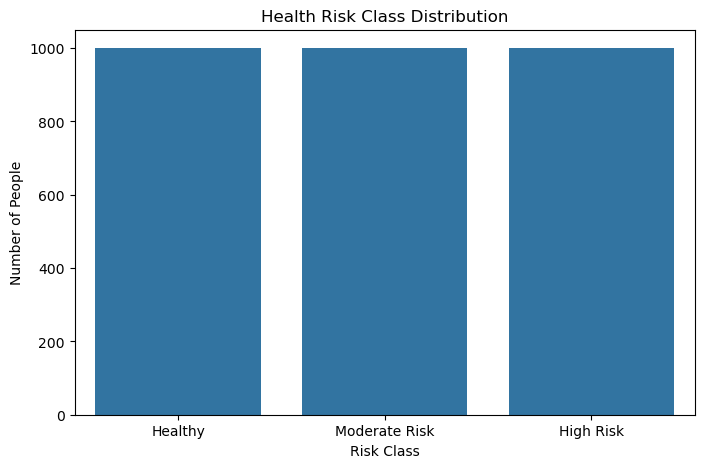

In [34]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Risk_Class",
    order=["Healthy", "Moderate Risk", "High Risk"]
)

plt.title("Health Risk Class Distribution")
plt.xlabel("Risk Class")
plt.ylabel("Number of People")
plt.show()


In [35]:
# Check whether classes are balanced
counts = df["Risk_Class"].value_counts()

print("Minimum class count:", counts.min())
print("Maximum class count:", counts.max())

if counts.max() / counts.min() < 1.5:
    print("✅ Dataset is reasonably balanced")
else:
    print("⚠️ Dataset is imbalanced")

Minimum class count: 1000
Maximum class count: 1000
✅ Dataset is reasonably balanced


#### BMI Distribution

In [36]:
df["BMI"].describe()

count    3000.000000
mean       24.599467
std         4.128493
min        16.000000
25%        21.775000
50%        24.500000
75%        27.400000
max        38.300000
Name: BMI, dtype: float64

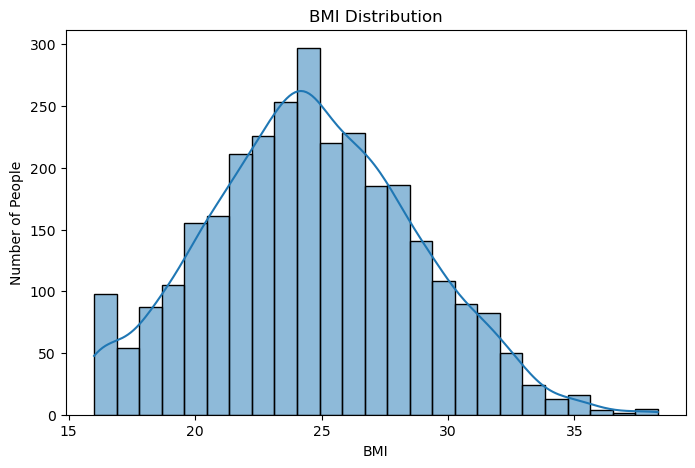

In [37]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="BMI",
    bins=25,
    kde=True
)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of People")

plt.show()

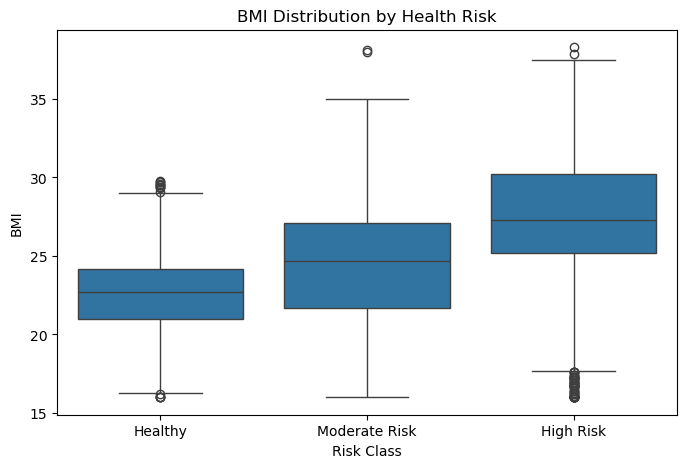

In [38]:
plt.figure(figsize=(8, 5)) ## bmi by risk class

sns.boxplot(
    data=df,
    x="Risk_Class",
    y="BMI",
    order=["Healthy", "Moderate Risk", "High Risk"]
)

plt.title("BMI Distribution by Health Risk")
plt.xlabel("Risk Class")
plt.ylabel("BMI")

plt.show()

In [39]:
df.groupby("Risk_Class")["BMI"].mean().round(2)

Risk_Class
Healthy          22.62
High Risk        26.90
Moderate Risk    24.28
Name: BMI, dtype: float64

#### Calories vs Risk

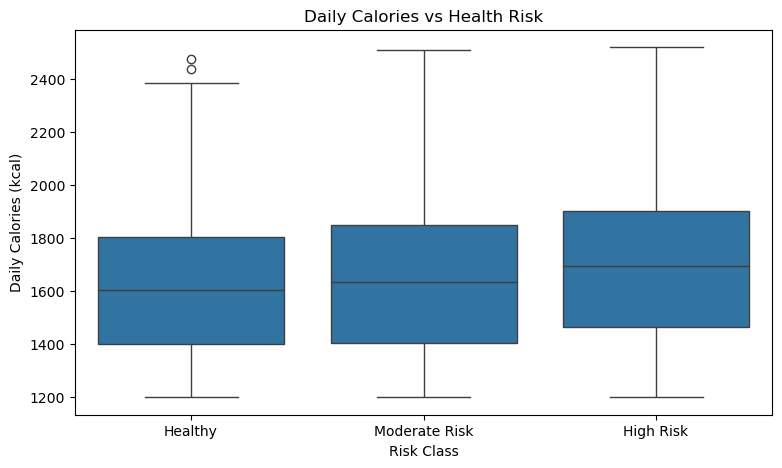

In [40]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Risk_Class",
    y="Daily_Calories_kcal",
    order=["Healthy", "Moderate Risk", "High Risk"]
)

plt.title("Daily Calories vs Health Risk")
plt.xlabel("Risk Class")
plt.ylabel("Daily Calories (kcal)")

plt.show()

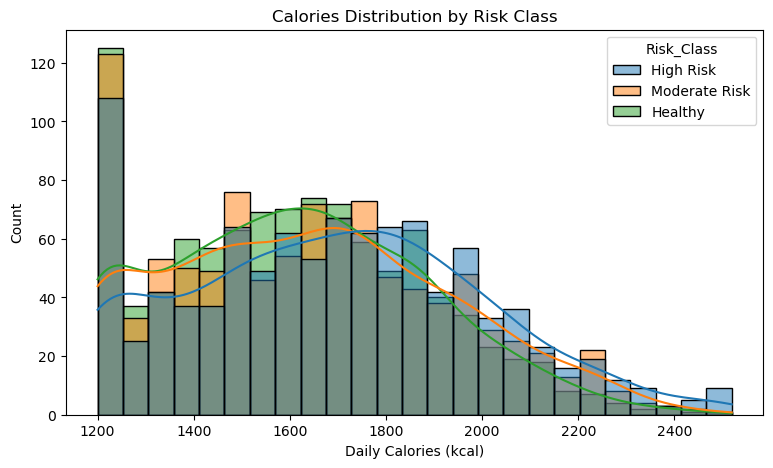

In [41]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Daily_Calories_kcal",
    hue="Risk_Class",
    bins=25,
    kde=True
)

plt.title("Calories Distribution by Risk Class")
plt.xlabel("Daily Calories (kcal)")
plt.ylabel("Count")

plt.show()

#### Sleep vs Risk

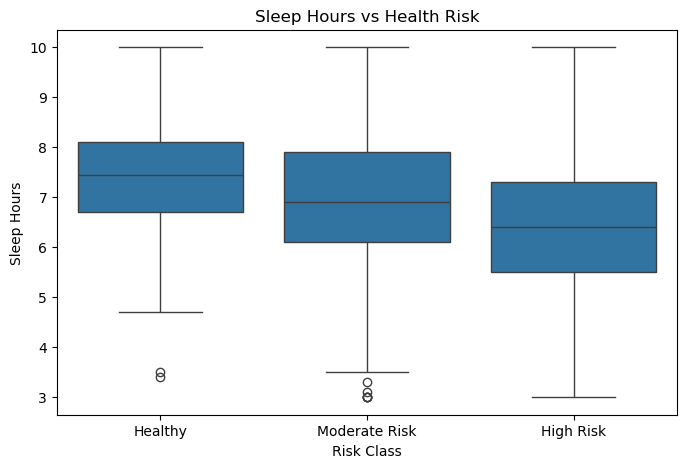

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Risk_Class",
    y="Sleep_Hours",
    order=["Healthy", "Moderate Risk", "High Risk"]
)

plt.title("Sleep Hours vs Health Risk")
plt.xlabel("Risk Class")
plt.ylabel("Sleep Hours")

plt.show()

In [42]:
df.groupby("Risk_Class")["Sleep_Hours"].mean().round(2)

Risk_Class
Healthy          7.38
High Risk        6.48
Moderate Risk    6.99
Name: Sleep_Hours, dtype: float64

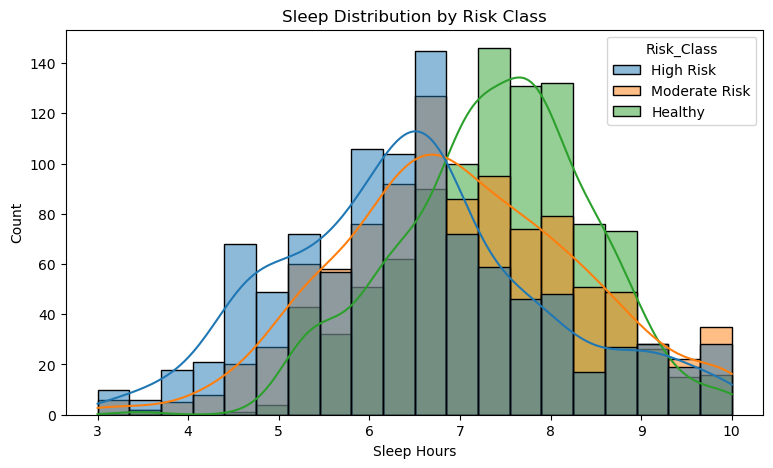

In [43]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Sleep_Hours",
    hue="Risk_Class",
    bins=20,
    kde=True
)

plt.title("Sleep Distribution by Risk Class")
plt.xlabel("Sleep Hours")
plt.ylabel("Count")

plt.show()

#### Steps vs Risk

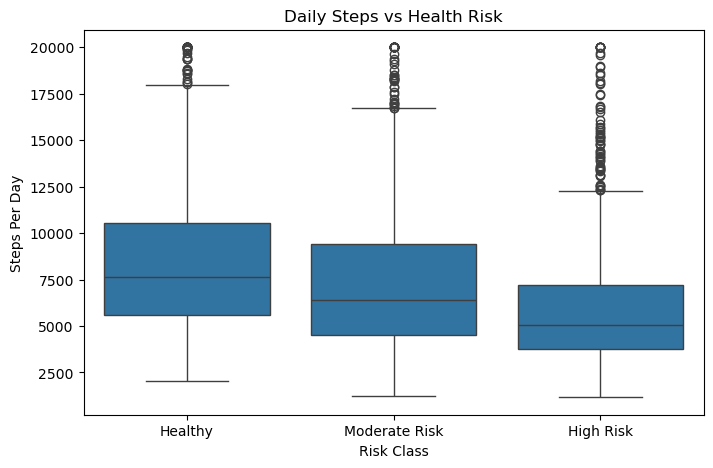

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Risk_Class",
    y="Steps_Per_Day",
    order=["Healthy", "Moderate Risk", "High Risk"]
)

plt.title("Daily Steps vs Health Risk")
plt.xlabel("Risk Class")
plt.ylabel("Steps Per Day")

plt.show()


In [45]:
df.groupby("Risk_Class")["Steps_Per_Day"].mean().round(0)

Risk_Class
Healthy          8633.0
High Risk        6021.0
Moderate Risk    7479.0
Name: Steps_Per_Day, dtype: float64

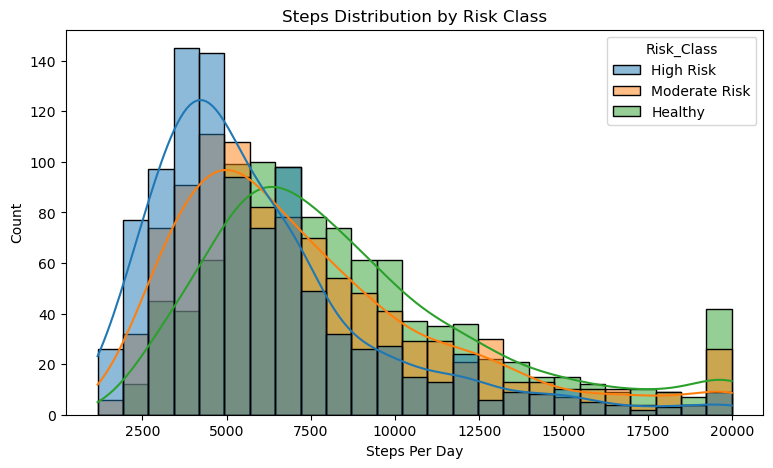

In [46]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Steps_Per_Day",
    hue="Risk_Class",
    bins=25,
    kde=True
)

plt.title("Steps Distribution by Risk Class")
plt.xlabel("Steps Per Day")
plt.ylabel("Count")

plt.show()

In [47]:
pd.crosstab(
    df["Activity_Level"],
    df["Risk_Class"],
    normalize="index"
).round(2)

Risk_Class,Healthy,High Risk,Moderate Risk
Activity_Level,,,
Active,0.47,0.17,0.36
Light,0.28,0.39,0.33
Moderate,0.45,0.20,0.34
Sedentary,0.12,0.59,0.28


#### Protein & Fiber vs Risk

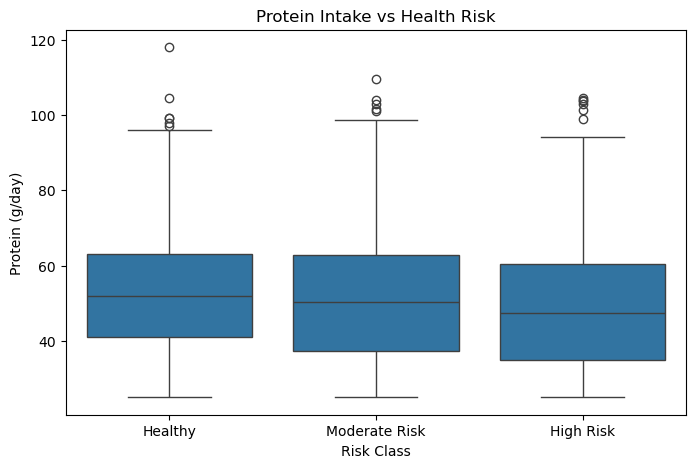

In [48]:
#  Protein vs Risk — Boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Risk_Class",
    y="Protein_g",
    order=["Healthy", "Moderate Risk", "High Risk"]
)

plt.title("Protein Intake vs Health Risk")
plt.xlabel("Risk Class")
plt.ylabel("Protein (g/day)")

plt.show()

In [49]:
# Average Protein by Risk
df.groupby("Risk_Class")["Protein_g"].mean().round(2)

Risk_Class
Healthy          52.71
High Risk        48.72
Moderate Risk    51.02
Name: Protein_g, dtype: float64

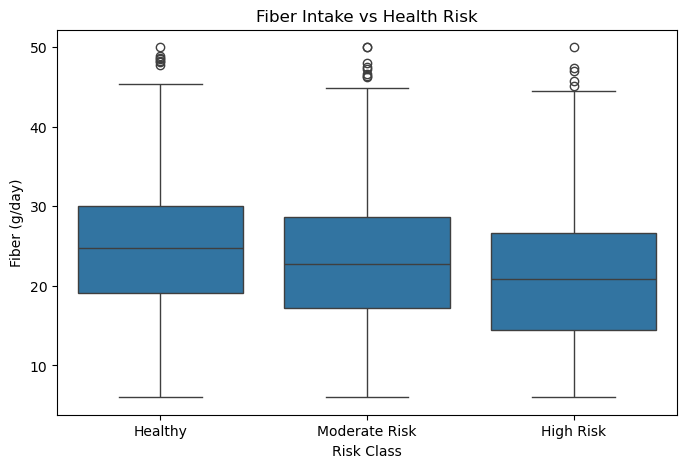

In [50]:
# Fiber vs Risk — Boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Risk_Class",
    y="Fiber_g",
    order=["Healthy", "Moderate Risk", "High Risk"]
)

plt.title("Fiber Intake vs Health Risk")
plt.xlabel("Risk Class")
plt.ylabel("Fiber (g/day)")

plt.show()

In [51]:
# Average Fiber by Risk
df.groupby("Risk_Class")["Fiber_g"].mean().round(2)

Risk_Class
Healthy          24.87
High Risk        20.88
Moderate Risk    22.87
Name: Fiber_g, dtype: float64

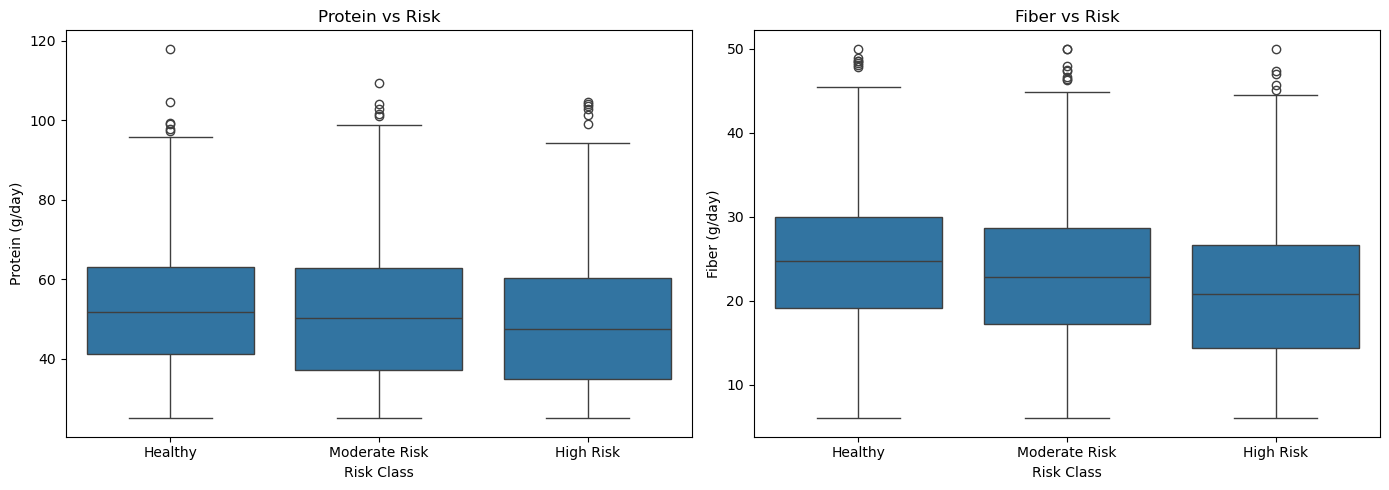

In [52]:
## Protein + Fiber comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="Risk_Class",
    y="Protein_g",
    order=["Healthy", "Moderate Risk", "High Risk"],
    ax=axes[0]
)

axes[0].set_title("Protein vs Risk")
axes[0].set_xlabel("Risk Class")
axes[0].set_ylabel("Protein (g/day)")

sns.boxplot(
    data=df,
    x="Risk_Class",
    y="Fiber_g",
    order=["Healthy", "Moderate Risk", "High Risk"],
    ax=axes[1]
)

axes[1].set_title("Fiber vs Risk")
axes[1].set_xlabel("Risk Class")
axes[1].set_ylabel("Fiber (g/day)")

plt.tight_layout()
plt.show()

####  Correlation Matrix 


In [53]:
numeric_cols = [
    "Age",
    "BMI",
    "Daily_Calories_kcal",
    "Protein_g",
    "Fiber_g",
    "Fat_g",
    "Iron_mg",
    "Calcium_mg",
    "Water_L",
    "Steps_Per_Day",
    "Sleep_Hours"
]

corr = df[numeric_cols].corr()

corr

,Age,BMI,Daily_Calories_kcal,Protein_g,Fiber_g,Fat_g,Iron_mg,Calcium_mg,Water_L,Steps_Per_Day,Sleep_Hours
Age,1.000000,0.002057,0.076475,0.013296,0.009649,0.018861,-0.011964,-0.030486,0.010315,0.024754,-0.032389
BMI,0.002057,1.000000,0.446638,0.155224,-0.001304,0.063766,-0.006106,0.028475,-0.007568,-0.006712,0.004027
Daily_Calories_kcal,0.076475,0.446638,1.000000,0.211788,-0.009045,0.119651,0.011441,-0.010165,-0.003871,0.026175,-0.010944
Protein_g,0.013296,0.155224,0.211788,1.000000,0.014117,0.033833,0.021581,0.010232,0.001309,-0.018334,0.030925
Fiber_g,0.009649,-0.001304,-0.009045,0.014117,1.000000,0.015509,-0.005031,-0.024104,-0.006363,0.157299,0.030756
Fat_g,0.018861,0.063766,0.119651,0.033833,0.015509,1.000000,-0.019356,-0.031652,0.035335,-0.002246,0.021568
Iron_mg,-0.011964,-0.006106,0.011441,0.021581,-0.005031,-0.019356,1.000000,0.020095,0.001821,-0.016338,0.012608
Calcium_mg,-0.030486,0.028475,-0.010165,0.010232,-0.024104,-0.031652,0.020095,1.000000,0.012152,0.027074,0.030379
Water_L,0.010315,-0.007568,-0.003871,0.001309,-0.006363,0.035335,0.001821,0.012152,1.000000,-0.021058,0.006651
Steps_Per_Day,0.024754,-0.006712,0.026175,-0.018334,0.157299,-0.002246,-0.016338,0.027074,-0.021058,1.000000,0.013940


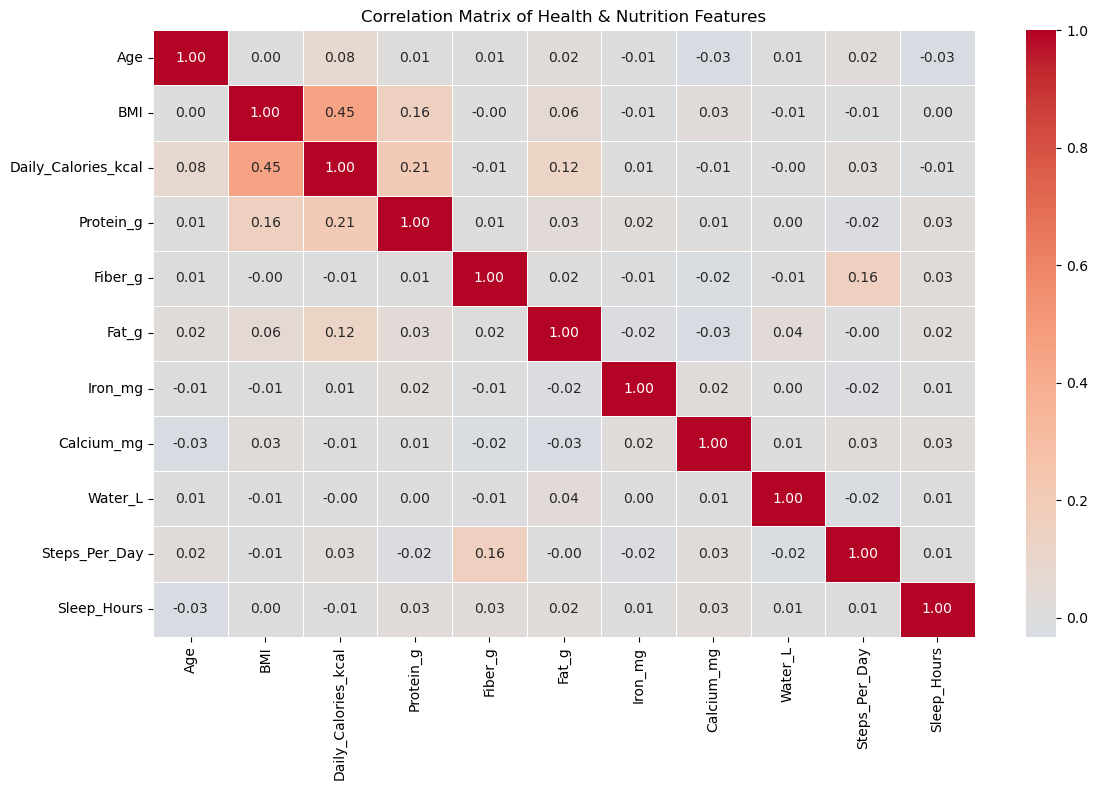

In [54]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Health & Nutrition Features")
plt.tight_layout()
plt.show()

In [55]:
corr_pairs = corr.unstack()

corr_pairs = corr_pairs[
    corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)
]

corr_pairs = corr_pairs.sort_values(
    key=lambda x: x.abs(),
    ascending=False
)

corr_pairs.head(20)

BMI                  Daily_Calories_kcal    0.446638
Daily_Calories_kcal  BMI                    0.446638
                     Protein_g              0.211788
Protein_g            Daily_Calories_kcal    0.211788
Steps_Per_Day        Fiber_g                0.157299
Fiber_g              Steps_Per_Day          0.157299
BMI                  Protein_g              0.155224
Protein_g            BMI                    0.155224
Daily_Calories_kcal  Fat_g                  0.119651
Fat_g                Daily_Calories_kcal    0.119651
Age                  Daily_Calories_kcal    0.076475
Daily_Calories_kcal  Age                    0.076475
BMI                  Fat_g                  0.063766
Fat_g                BMI                    0.063766
Water_L              Fat_g                  0.035335
Fat_g                Water_L                0.035335
Protein_g            Fat_g                  0.033833
Fat_g                Protein_g              0.033833
Age                  Sleep_Hours           -0.

#### Outlier Detection

In [57]:
outlier_cols = [
    "Age",
    "BMI",
    "Daily_Calories_kcal",
    "Protein_g",
    "Fiber_g",
    "Fat_g",
    "Iron_mg",
    "Calcium_mg",
    "Water_L",
    "Steps_Per_Day",
    "Sleep_Hours"
]

outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": len(outliers),
        "Outlier %": round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Age,31.00,57.00,-8.00,96.00,0,0.00
1,BMI,21.78,27.40,13.34,35.84,10,0.33
2,Daily_Calories_kcal,1416.00,1854.00,759.00,2511.00,2,0.07
3,Protein_g,37.50,62.40,0.15,99.75,12,0.40
4,Fiber_g,16.80,28.60,-0.90,46.30,17,0.57
5,Fat_g,47.00,77.03,1.96,122.06,13,0.43
6,Iron_mg,8.98,15.20,-0.36,24.54,6,0.20
7,Calcium_mg,679.75,1013.25,179.50,1513.50,0,0.00
8,Water_L,1.61,2.62,0.09,4.14,6,0.20
9,Steps_Per_Day,4457.75,9259.25,-2744.50,16461.50,150,5.00


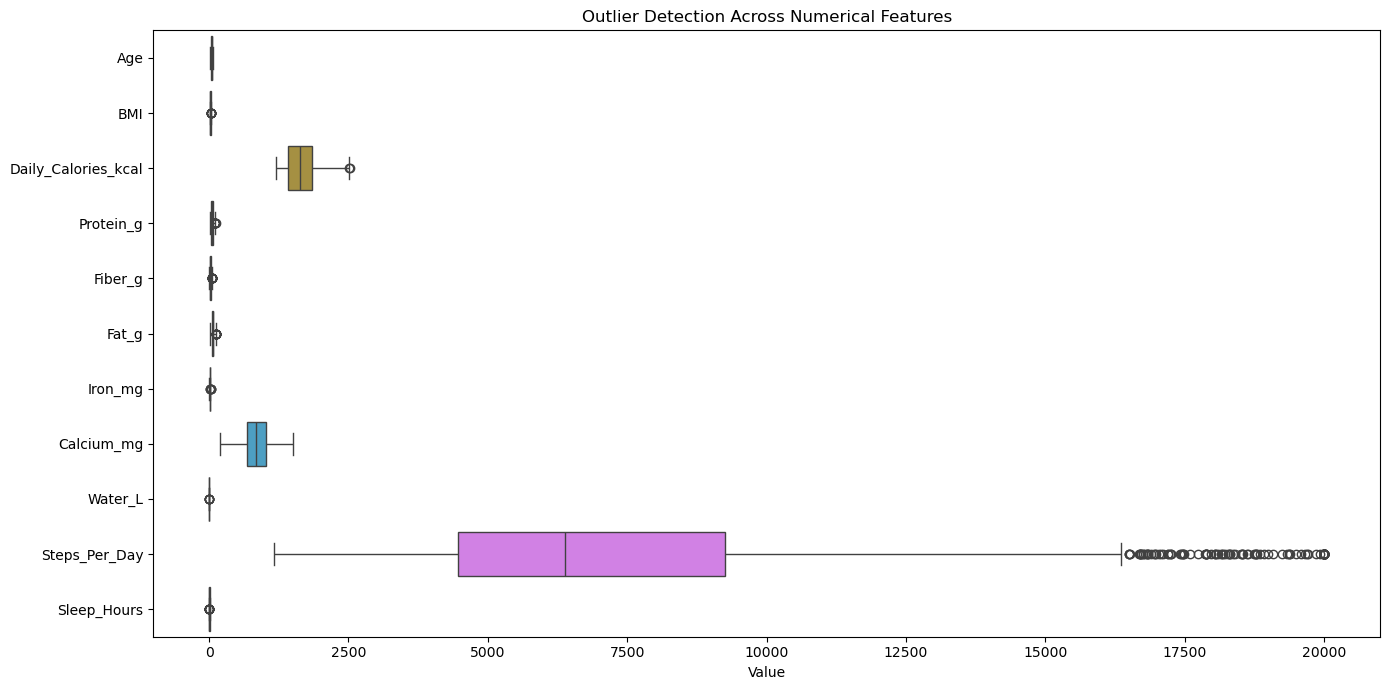

In [58]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df[outlier_cols],
    orient="h"
)

plt.title("Outlier Detection Across Numerical Features")
plt.xlabel("Value")

plt.tight_layout()
plt.show()

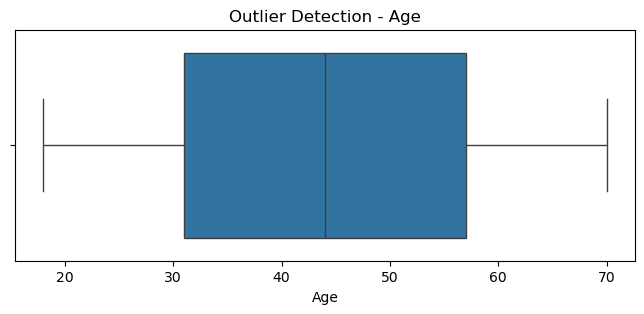

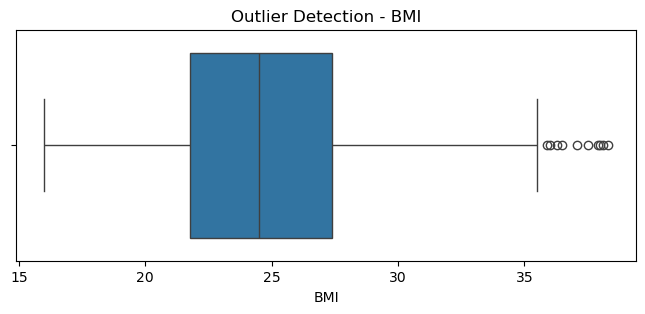

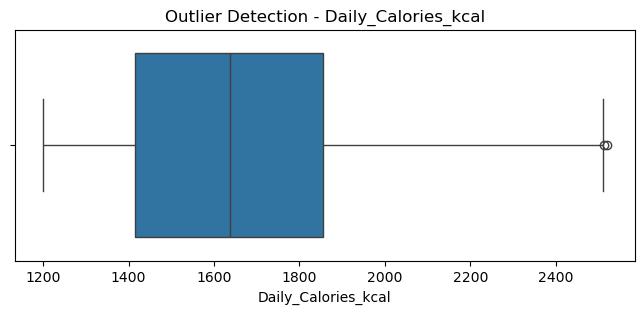

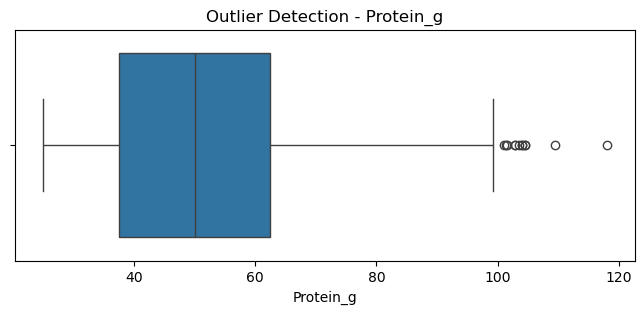

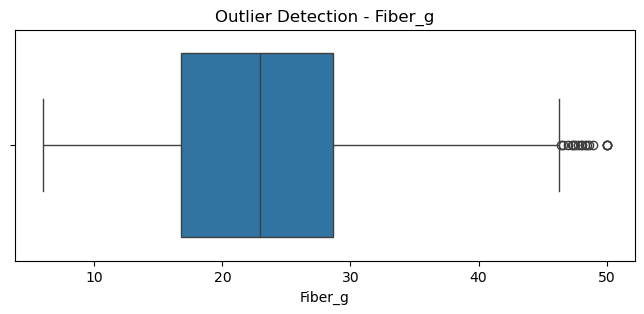

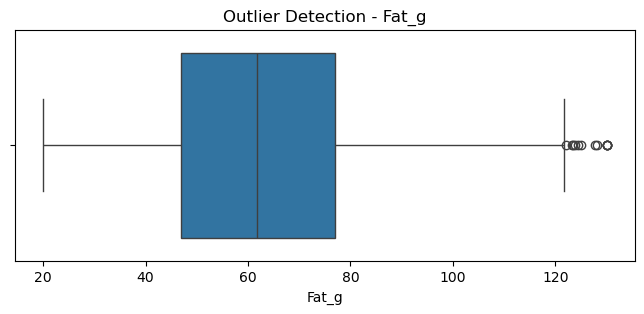

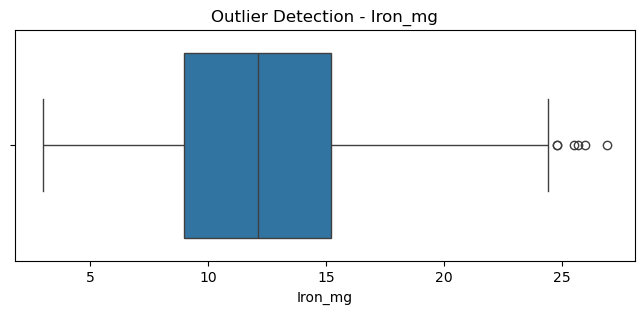

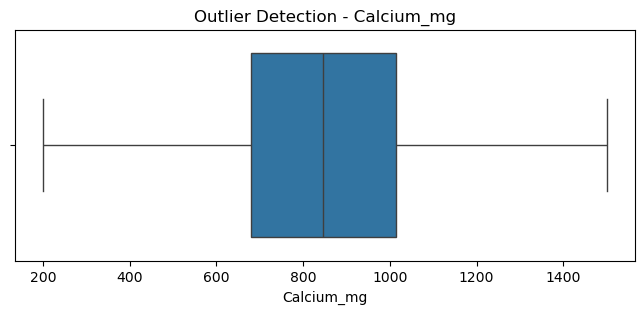

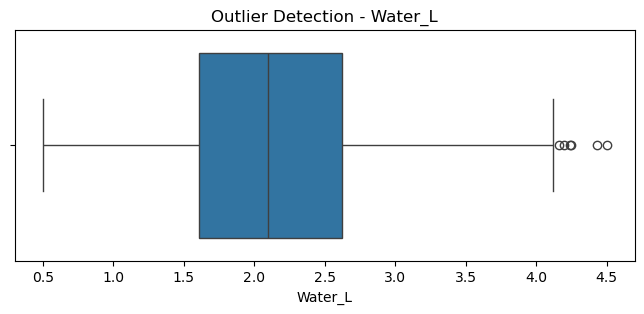

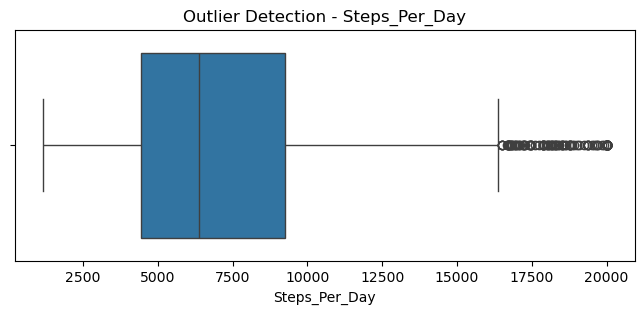

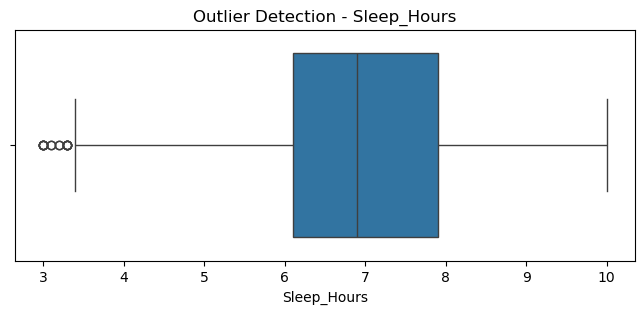

In [59]:
for col in outlier_cols:
    plt.figure(figsize=(8, 3))

    sns.boxplot(x=df[col])

    plt.title(f"Outlier Detection - {col}")
    plt.xlabel(col)

    plt.show()

#### Feature Distribution

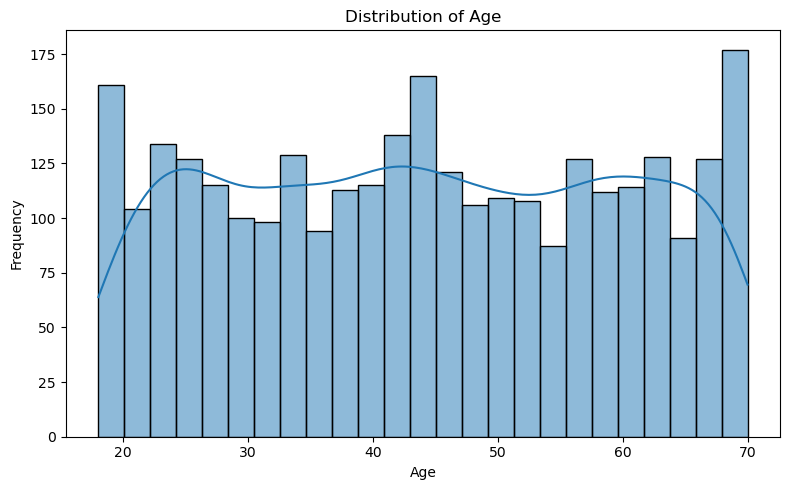

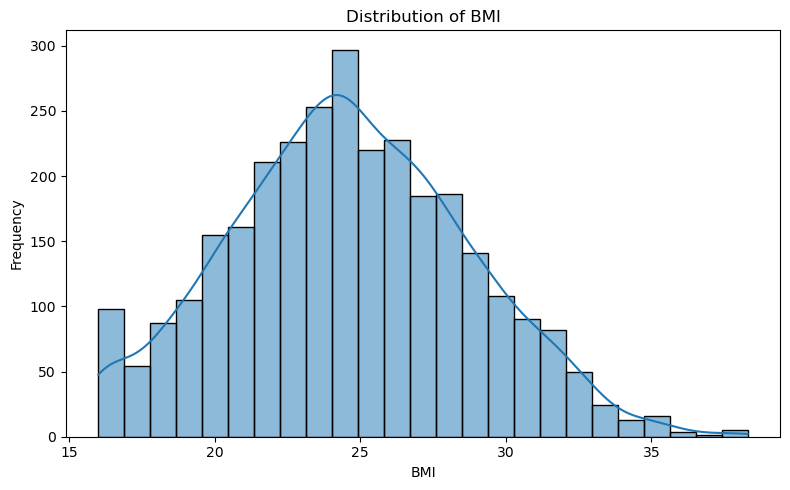

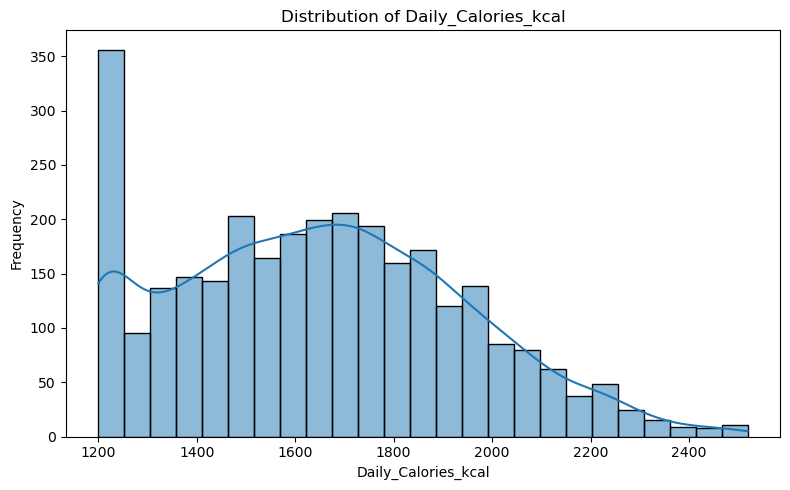

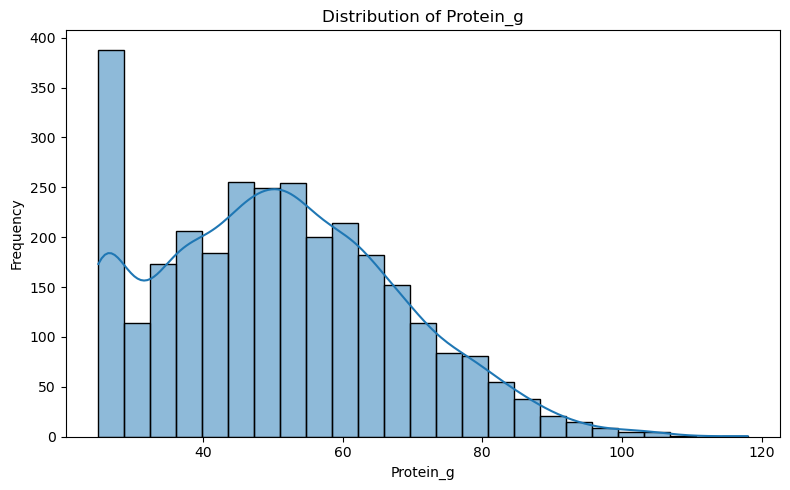

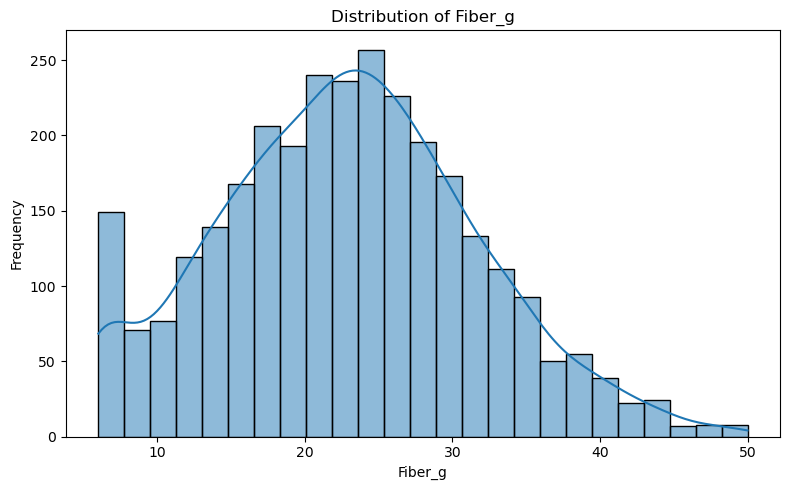

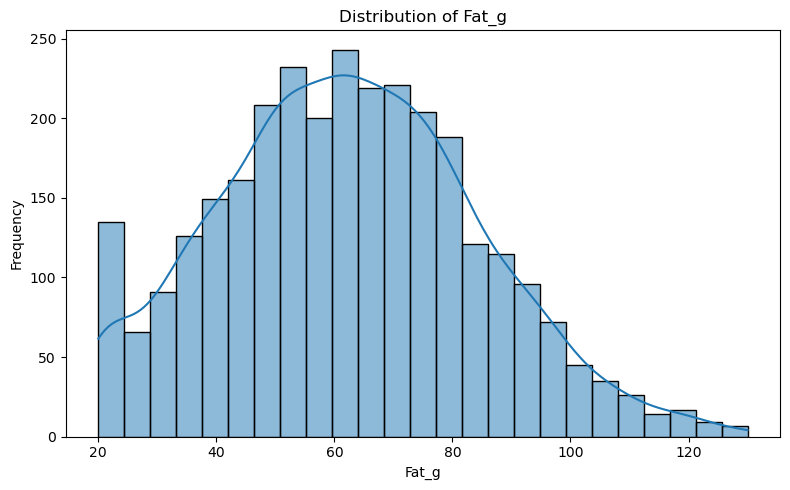

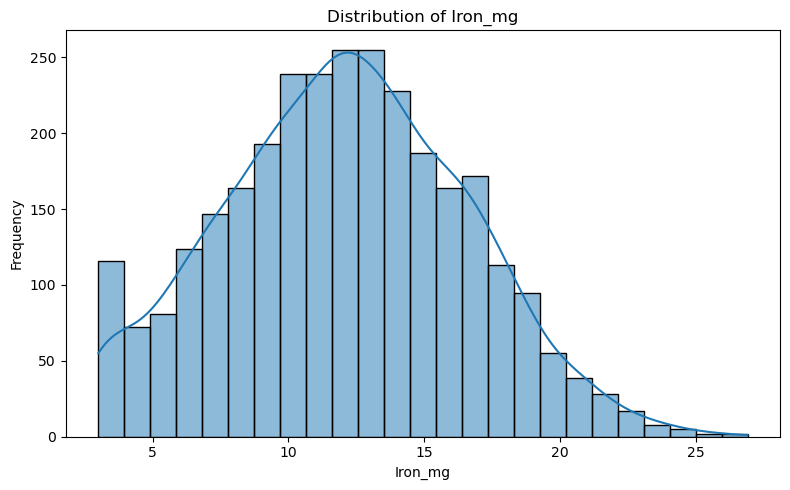

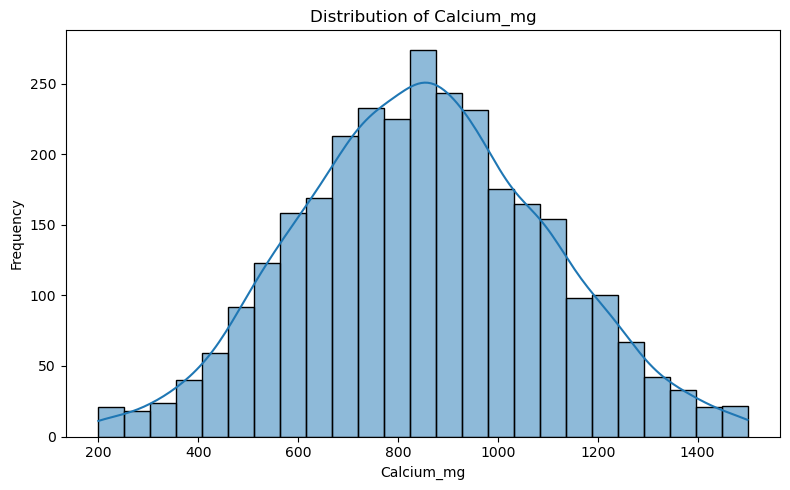

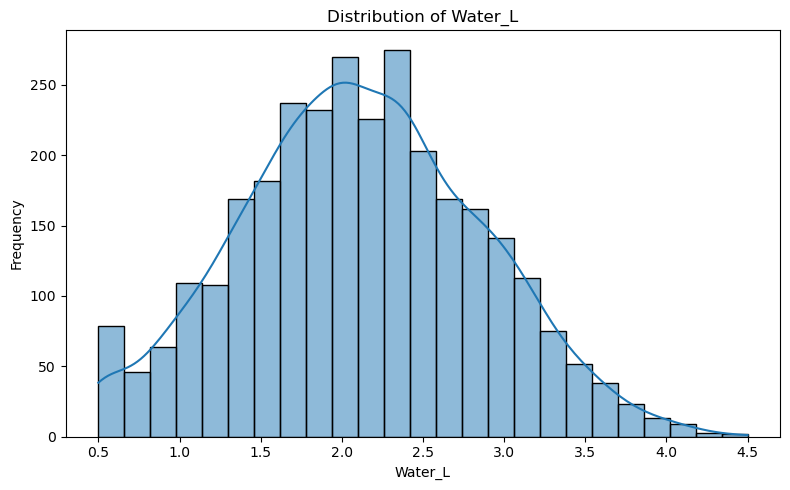

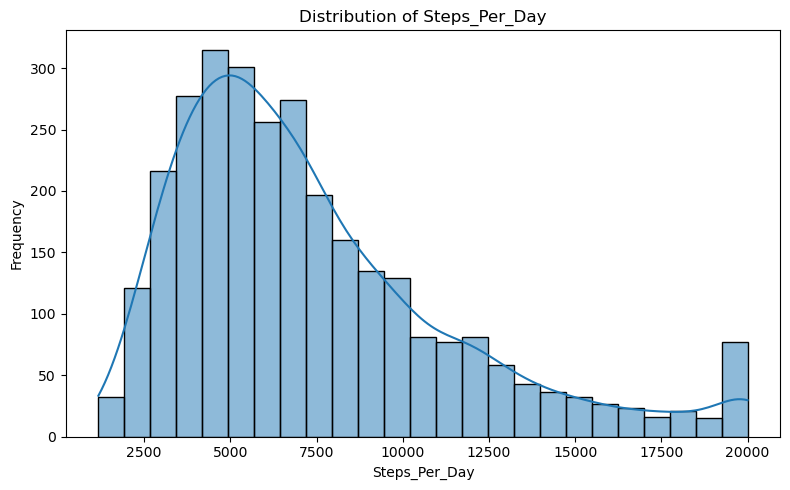

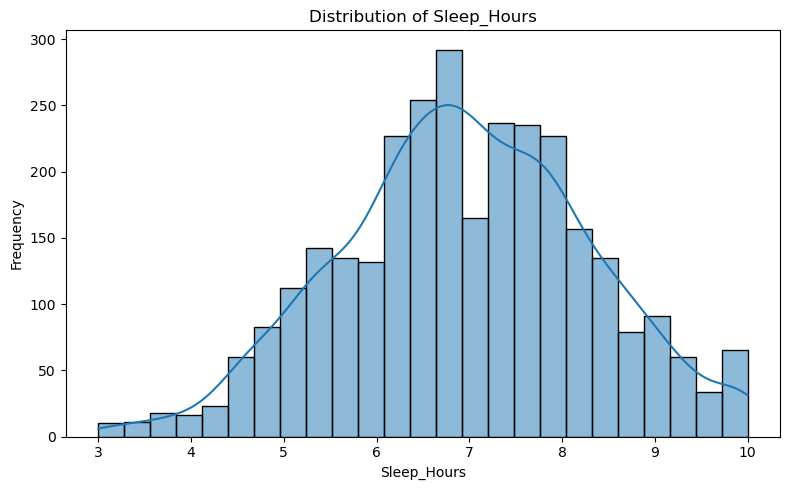

In [60]:
numeric_cols = [
    "Age",
    "BMI",
    "Daily_Calories_kcal",
    "Protein_g",
    "Fiber_g",
    "Fat_g",
    "Iron_mg",
    "Calcium_mg",
    "Water_L",
    "Steps_Per_Day",
    "Sleep_Hours"
]
for col in numeric_cols:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        bins=25,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

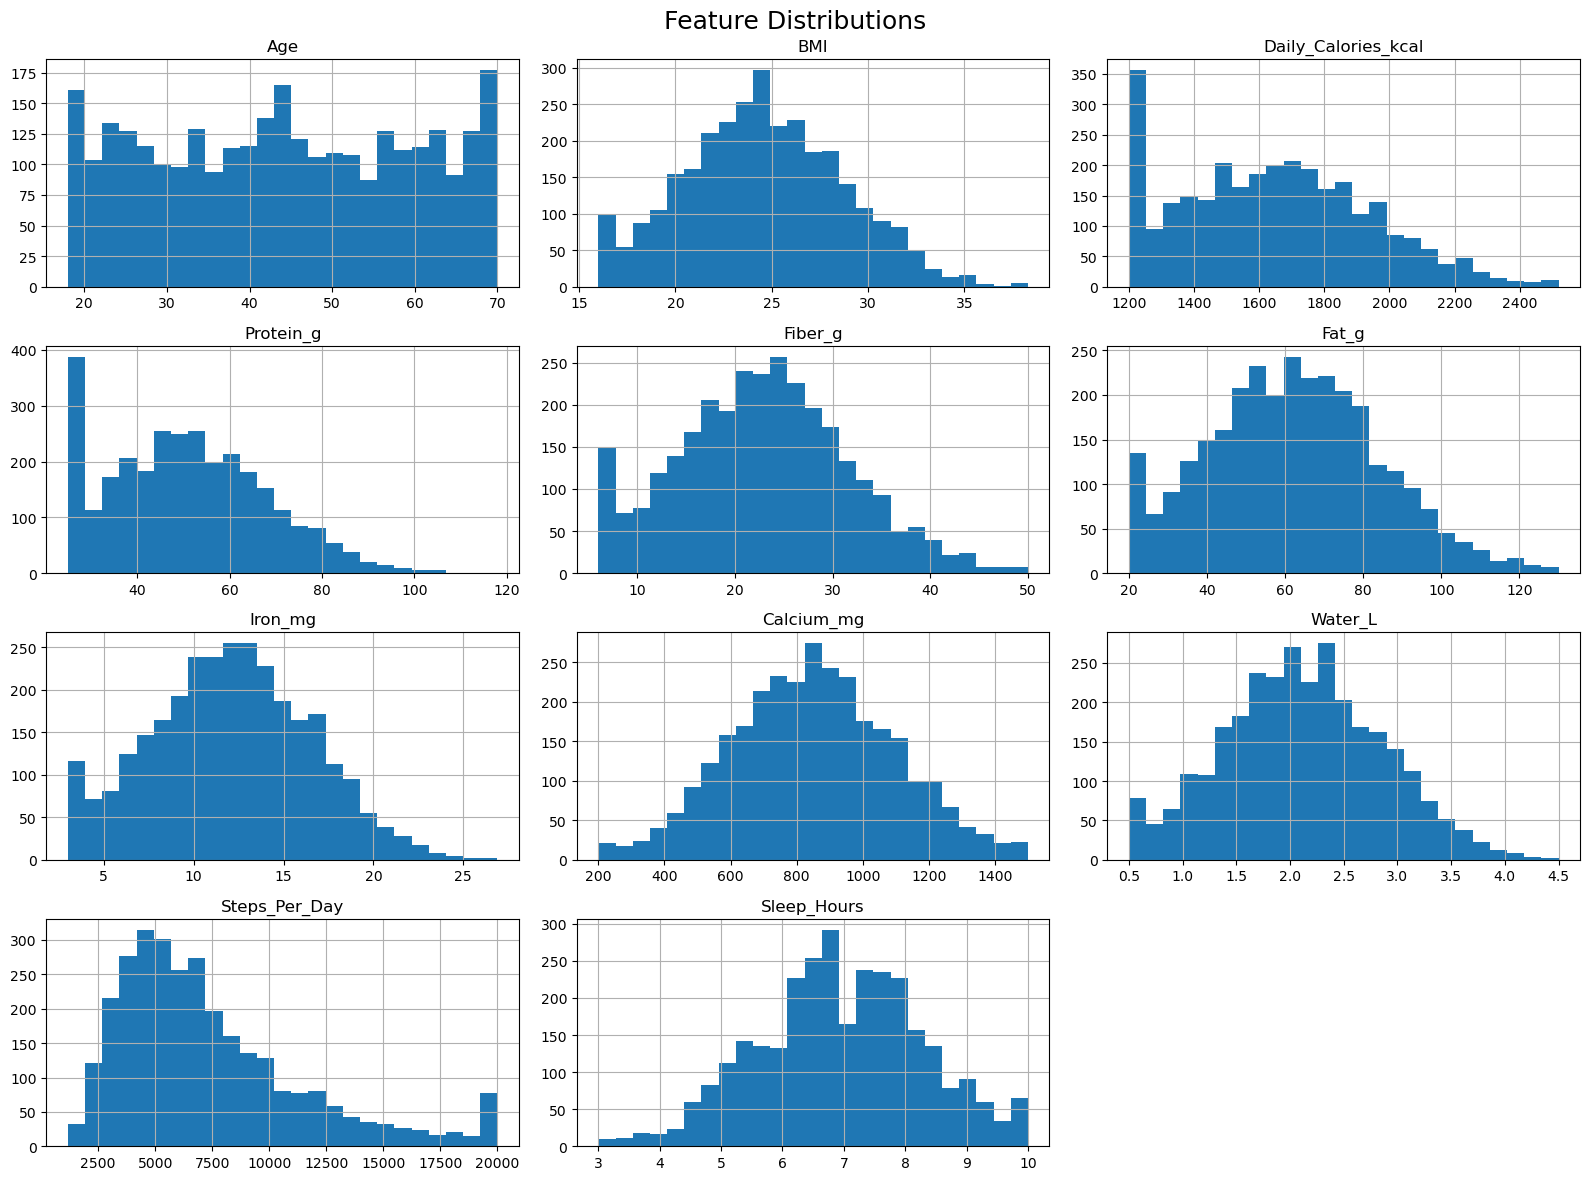

In [61]:
df[numeric_cols].hist(
    figsize=(16, 12),
    bins=25
)

plt.suptitle(
    "Feature Distributions",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [62]:
skewness = df[numeric_cols].skew().sort_values(ascending=False)

print(skewness)

Steps_Per_Day          1.236429
Protein_g              0.372114
Daily_Calories_kcal    0.300281
Fat_g                  0.206030
Fiber_g                0.173576
BMI                    0.131554
Water_L                0.081563
Iron_mg                0.074483
Calcium_mg             0.050070
Age                    0.010373
Sleep_Hours           -0.069534
dtype: float64


## 4. Model Preparation

EDA Complete
     ↓
1. Define Target Column
     ↓
2. Define Features
     ↓
3. X and y Separate
     ↓
4. Train-Test Split
     ↓
5. Identify Numerical & Categorical Features
     ↓
6. Preprocessing
     │
     ├── Numerical → StandardScaler
     │
     └── Categorical → OneHotEncoder
     ↓
7. ColumnTransformer
     ↓
8. ML Pipeline
     ↓
9. Train Multiple Models
     │
     ├── Logistic Regression
     ├── Random Forest
     └── Gradient Boosting
     ↓
10. Model Evaluation
     │
     ├── Accuracy
     ├── Precision
     ├── Recall
     ├── F1 Score
     ├── Confusion Matrix
     └── ROC-AUC
     ↓
11. Cross Validation
     ↓
12. Hyperparameter Tuning
     ↓
13. Compare Models
     ↓
14. Select Best Model
     ↓
15. Save Complete Pipeline
     ↓
16. Test with New User Input

#### 1. Target Column

In [67]:
target = "Risk_Class"
print("Healthy ")
print("Moderate Risk")
print("High Risk")

Healthy 
Moderate Risk
High Risk


#### 2. Features

In [69]:
features = [
    "Age",
    "Gender",
    "BMI",
    "Daily_Calories_kcal",
    "Protein_g",
    "Fiber_g",
    "Fat_g",
    "Iron_mg",
    "Calcium_mg",
    "Water_L",
    "Steps_Per_Day",
    "Sleep_Hours",
    "Activity_Level"
]


#### 3. X & y

In [70]:
X = df[features]
y = df[target]

#### 4. Train-Test Split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#### 5. Feature Types

In [72]:
# Numerical
numerical_features = [
    "Age",
    "BMI",
    "Daily_Calories_kcal",
    "Protein_g",
    "Fiber_g",
    "Fat_g",
    "Iron_mg",
    "Calcium_mg",
    "Water_L",
    "Steps_Per_Day",
    "Sleep_Hours"
]

In [73]:
# Categorical
categorical_features = [
    "Gender",
    "Activity_Level"
]

#### 6. Preprocessing

##### Preprocessing Pipelines for Numerical and Categorical Features

In [74]:
# Preprocessing Pipelines for Numerical 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numerical_features = [
    "Age",
    "BMI",
    "Daily_Calories_kcal",
    "Protein_g",
    "Fiber_g",
    "Fat_g",
    "Iron_mg",
    "Calcium_mg",
    "Water_L",
    "Steps_Per_Day",
    "Sleep_Hours"
]


In [75]:
categorical_features = [
    "Gender",
    "Activity_Level"
]

In [76]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

#### Column Transformation

In [77]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

#### ML Pipline

In [78]:
# 1. Libraries

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
# 2. Logistic Regression Pipeline

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])


In [80]:
# 3. Random Forest Pipeline

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [81]:
# 4. Gradient Boosting Pipeline

gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

In [ ]:
# 1. Logistic Regression train

logistic_pipeline.fit(X_train, y_train)

print("✅ Logistic Regression trained")

✅ Logistic Regression trained


In [84]:
# 2. Random Forest train

random_forest_pipeline.fit(X_train, y_train)

print("✅ Random Forest trained")

✅ Random Forest trained


In [83]:
# 3. Gradient Boosting train

gradient_boosting_pipeline.fit(X_train, y_train)

print("✅ Gradient Boosting trained")

✅ Gradient Boosting trained


In [85]:
# Combining all models into a dictionary for easy access

models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline
}

In [86]:
print("Models trained successfully:")
for name in models:
    print("✅", name)

Models trained successfully:
✅ Logistic Regression
✅ Random Forest
✅ Gradient Boosting


 #### Model Evaluation

In [87]:
## Required Libraries for Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [88]:
# Predicting on the test set for each model

predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)

print("✅ Predictions completed")

✅ Predictions completed


In [89]:
# Model comparison

results = []

for name, model in models.items():

    y_pred = predictions[name]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.753333,0.752749,0.753333,0.753029
2,Gradient Boosting,0.751667,0.754233,0.751667,0.752645
0,Logistic Regression,0.623333,0.616594,0.623333,0.618699


In [90]:
# Classification Report

for name, model in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    y_pred = predictions[name]

    print(
        classification_report(
            y_test,
            y_pred
        )
    )


Logistic Regression
               precision    recall  f1-score   support

      Healthy       0.64      0.67      0.65       200
    High Risk       0.69      0.75      0.72       200
Moderate Risk       0.52      0.45      0.48       200

     accuracy                           0.62       600
    macro avg       0.62      0.62      0.62       600
 weighted avg       0.62      0.62      0.62       600


Random Forest
               precision    recall  f1-score   support

      Healthy       0.82      0.82      0.82       200
    High Risk       0.80      0.80      0.80       200
Moderate Risk       0.64      0.64      0.64       200

     accuracy                           0.75       600
    macro avg       0.75      0.75      0.75       600
 weighted avg       0.75      0.75      0.75       600


Gradient Boosting
               precision    recall  f1-score   support

      Healthy       0.81      0.82      0.82       200
    High Risk       0.83      0.79      0.81       200
Mod

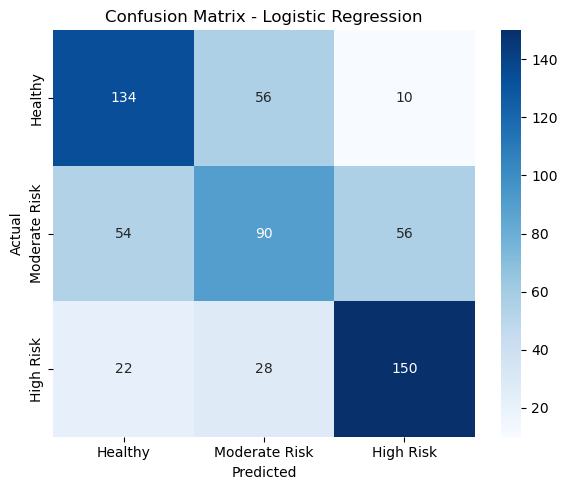

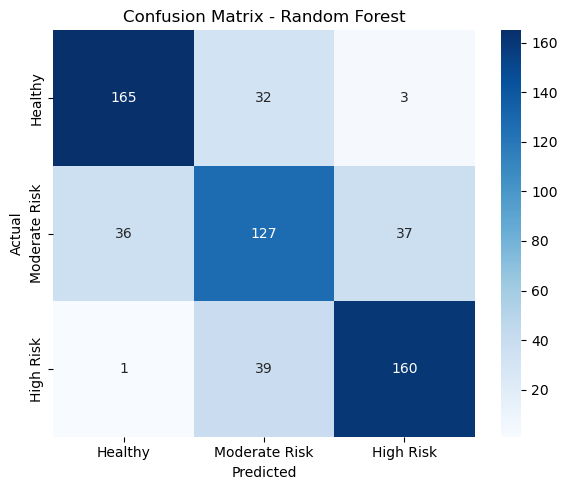

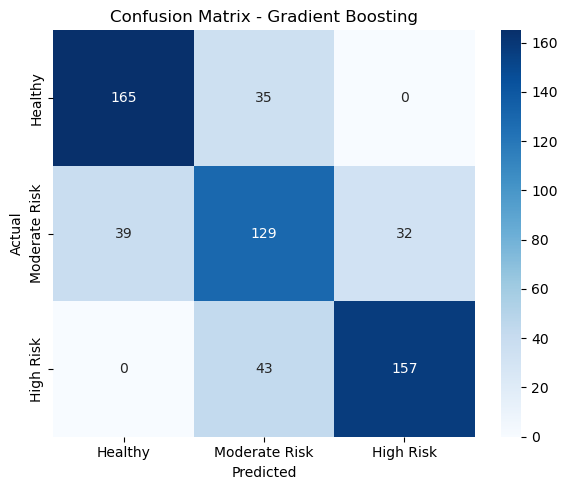

In [91]:
# Confusion Matrix

for name, model in models.items():

    y_pred = predictions[name]

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=["Healthy", "Moderate Risk", "High Risk"]
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Healthy", "Moderate Risk", "High Risk"],
        yticklabels=["Healthy", "Moderate Risk", "High Risk"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

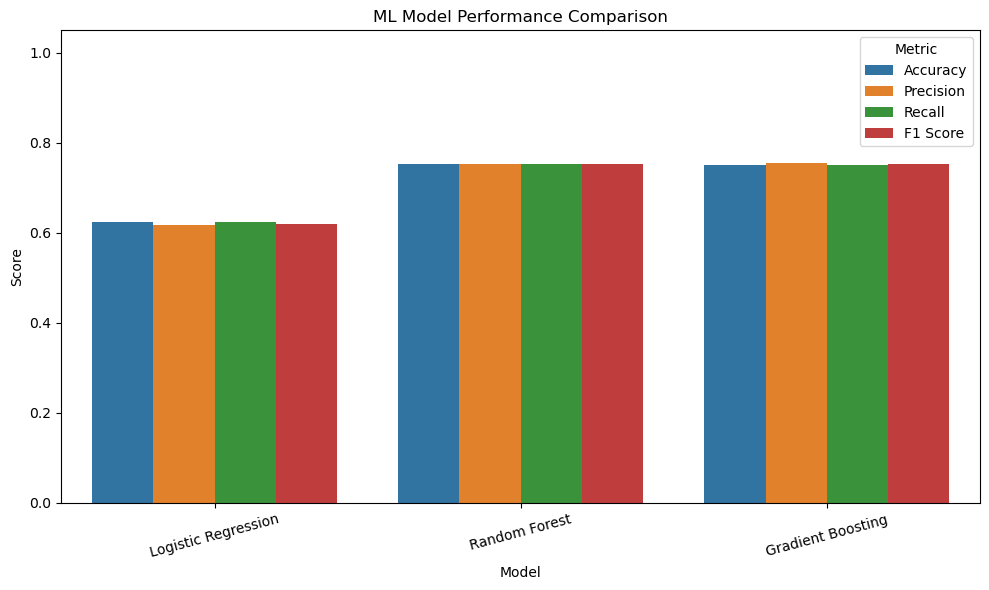

In [92]:
results_melted = results_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1.05)
plt.title("ML Model Performance Comparison")
plt.ylabel("Score")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Cross Validation

In [93]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv_scores = cross_val_score(
    random_forest_pipeline,
    X,
    y,
    cv=cv,
    scoring="f1_weighted"
)

print("Cross Validation F1 Scores:")
print(rf_cv_scores)

print("\nMean CV F1 Score:", rf_cv_scores.mean())
print("Std CV F1 Score:", rf_cv_scores.std())

Cross Validation F1 Scores:
[0.77969147 0.76386132 0.76000534 0.74804899 0.80856402]

Mean CV F1 Score: 0.7720342280466623
Std CV F1 Score: 0.020879853104502855


 ### Hyperparameter Tuning

In [94]:
from sklearn.model_selection import GridSearchCV

In [95]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [96]:
grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['Age',
                                                                          'BMI',
                                                                          'Daily_Calories_kcal',
                                                                          'Protein_g',
                                                                          'Fiber_g',
                                                                          'Fat_g',
                                                                          'Iron_mg',
                                                                          'Calcium_mg',
                                                                          'Water_L',
                                                                          'Steps_Per_Day',
                                                                          'Sleep_Hours']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Gender',
                                                                          'Activity_Level'])])),
                                       ('model',
                                        RandomForestClassifier(n_estimators=200,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             scoring='f1_weighted', verbose=1)

In [97]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 200}


In [98]:
print("Best CV F1 Score:")
print(grid_search.best_score_)

Best CV F1 Score:
0.7721788664414666


 ### Final Tuned Model Evaluation

In [99]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Best tuned model
best_model = grid_search.best_estimator_

# Predict on untouched test data
y_pred_final = best_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred_final)

precision = precision_score(
    y_test,
    y_pred_final,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred_final,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred_final,
    average="weighted"
)

print("Final Tuned Random Forest")
print("-" * 40)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Final Tuned Random Forest
----------------------------------------
Accuracy  : 0.7467
Precision : 0.7463
Recall    : 0.7467
F1 Score  : 0.7464


In [100]:
print(
    classification_report(
        y_test,
        y_pred_final
    )
)

               precision    recall  f1-score   support

      Healthy       0.82      0.81      0.81       200
    High Risk       0.79      0.81      0.80       200
Moderate Risk       0.63      0.62      0.63       200

     accuracy                           0.75       600
    macro avg       0.75      0.75      0.75       600
 weighted avg       0.75      0.75      0.75       600



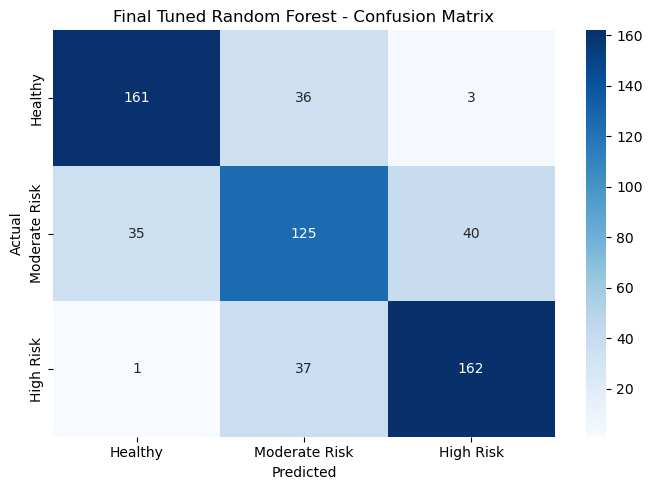

In [101]:
cm = confusion_matrix(
    y_test,
    y_pred_final,
    labels=[
        "Healthy",
        "Moderate Risk",
        "High Risk"
    ]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Healthy",
        "Moderate Risk",
        "High Risk"
    ],
    yticklabels=[
        "Healthy",
        "Moderate Risk",
        "High Risk"
    ]
)

plt.title("Final Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [102]:
# Get trained Random Forest model
rf_model = best_model.named_steps["model"]

# Get preprocessor
preprocessor_fitted = best_model.named_steps["preprocessor"]

# Get transformed feature names
feature_names = preprocessor_fitted.get_feature_names_out()

# Get feature importance
importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(15)

,Feature,Importance
1,num__BMI,0.332740
10,num__Sleep_Hours,0.128031
9,num__Steps_Per_Day,0.105702
4,num__Fiber_g,0.067712
3,num__Protein_g,0.061482
8,num__Water_L,0.056387
2,num__Daily_Calories_kcal,0.045311
6,num__Iron_mg,0.043733
7,num__Calcium_mg,0.043321
5,num__Fat_g,0.038682


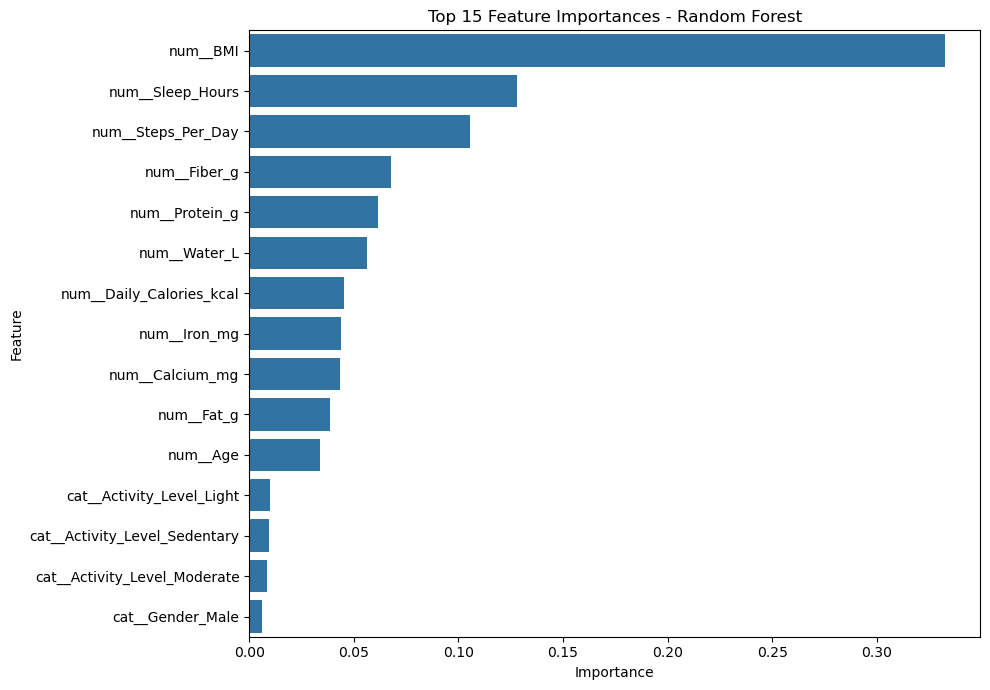

In [103]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [104]:
report = classification_report(
    y_test,
    y_pred_final,
    output_dict=True
)

report_df = pd.DataFrame(report).T

report_df

,precision,recall,f1-score,support
Healthy,0.817259,0.805000,0.811083,200.000000
High Risk,0.790244,0.810000,0.800000,200.000000
Moderate Risk,0.631313,0.625000,0.628141,200.000000
accuracy,0.746667,0.746667,0.746667,0.746667
macro avg,0.746272,0.746667,0.746408,600.000000
weighted avg,0.746272,0.746667,0.746408,600.000000


In [105]:
report_df.loc[
    ["Healthy", "Moderate Risk", "High Risk"],
    ["precision", "recall", "f1-score", "support"]
]

,precision,recall,f1-score,support
Healthy,0.817259,0.805,0.811083,200.0
Moderate Risk,0.631313,0.625,0.628141,200.0
High Risk,0.790244,0.810,0.800000,200.0


In [106]:
moderate_mask = y_test == "Moderate Risk"

moderate_actual = y_test[moderate_mask]
moderate_predicted = pd.Series(
    y_pred_final,
    index=y_test.index
)[moderate_mask]

pd.crosstab(
    moderate_actual,
    moderate_predicted
)

col_0,Healthy,High Risk,Moderate Risk
Risk_Class,,,
Moderate Risk,35,40,125


In [107]:
moderate_data = X_test[
    y_test == "Moderate Risk"
].copy()

moderate_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200.0,44.8400,14.848799,18.0,34.0000,45.00,57.0000,70.0
BMI,200.0,24.0545,3.917360,16.0,21.6000,24.25,26.9250,38.1
Daily_Calories_kcal,200.0,1637.6750,289.139791,1200.0,1409.0000,1621.00,1835.5000,2343.0
Protein_g,200.0,51.6380,18.418932,25.0,36.5500,51.40,63.6250,104.0
Fiber_g,200.0,22.2195,8.588070,6.0,16.5250,22.45,27.7000,44.5
Fat_g,200.0,61.8870,22.583149,20.0,46.1750,60.40,78.0250,128.2
Iron_mg,200.0,12.2060,4.720879,3.0,8.7500,12.40,15.7250,24.8
Calcium_mg,200.0,854.4550,266.501243,200.0,680.0000,851.00,1028.0000,1500.0
Water_L,200.0,2.1678,0.731796,0.5,1.7275,2.18,2.6525,4.2
Steps_Per_Day,200.0,7112.3900,3899.372078,1814.0,4363.7500,6313.00,8785.0000,20000.0


In [108]:
comparison = X_test.copy()

comparison["Risk_Class"] = y_test.values

comparison.groupby("Risk_Class")[
    [
        "BMI",
        "Daily_Calories_kcal",
        "Protein_g",
        "Fiber_g",
        "Fat_g",
        "Iron_mg",
        "Calcium_mg",
        "Water_L",
        "Steps_Per_Day",
        "Sleep_Hours"
    ]
].mean().round(2)

,BMI,Daily_Calories_kcal,Protein_g,Fiber_g,Fat_g,Iron_mg,Calcium_mg,Water_L,Steps_Per_Day,Sleep_Hours
Risk_Class,,,,,,,,,,
Healthy,22.80,1611.74,52.28,25.43,61.65,12.67,856.91,2.28,8598.09,7.42
High Risk,26.65,1695.82,47.73,20.85,62.79,11.32,830.60,2.00,6435.79,6.41
Moderate Risk,24.05,1637.68,51.64,22.22,61.89,12.21,854.46,2.17,7112.39,6.88


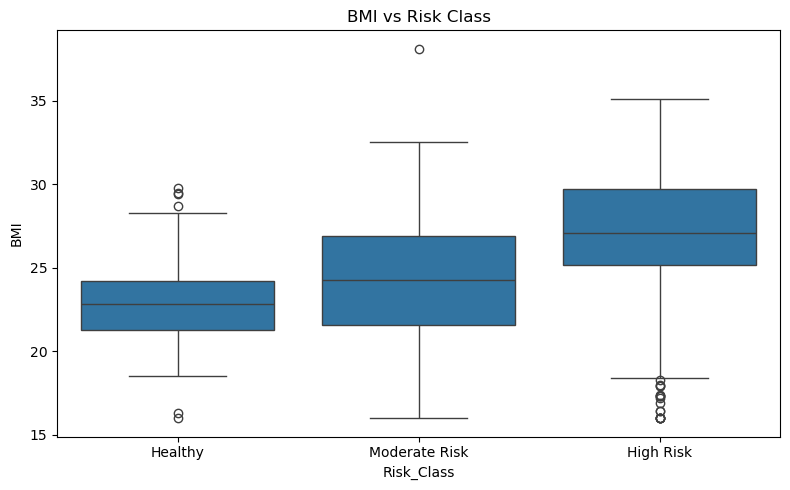

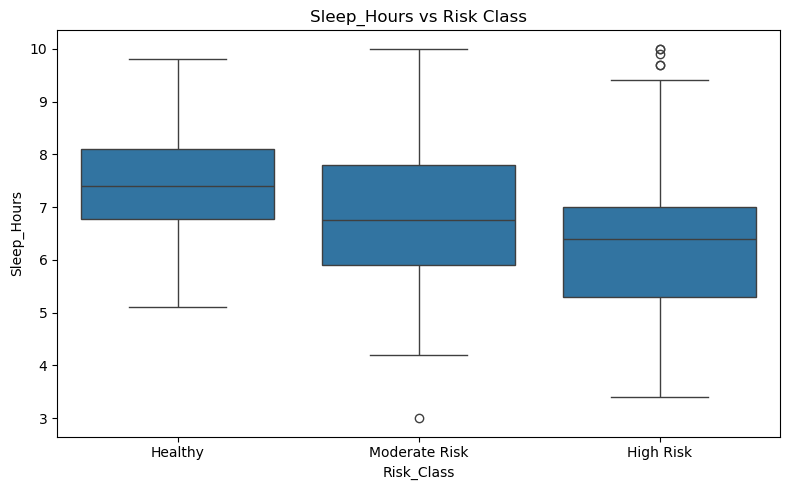

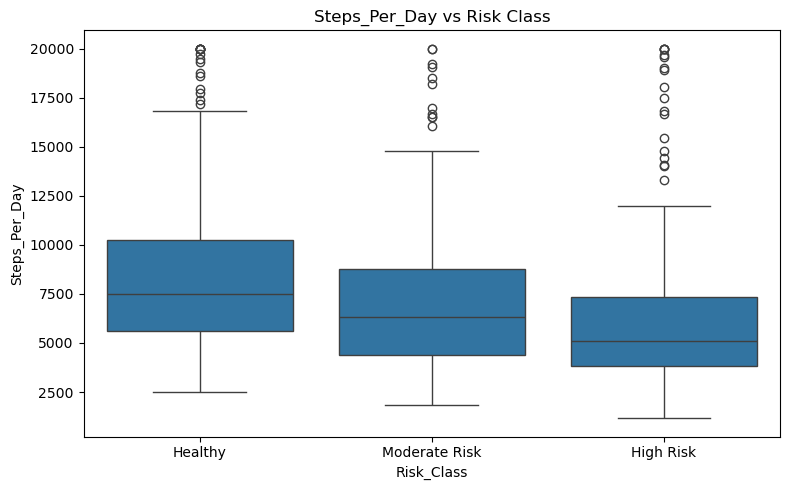

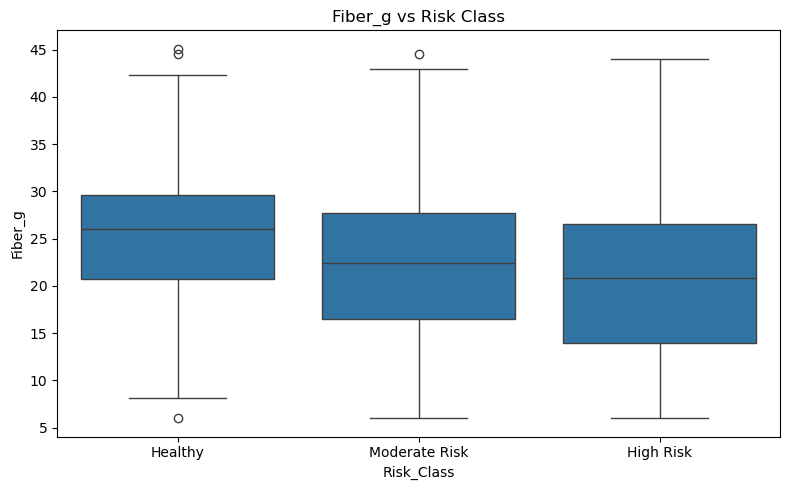

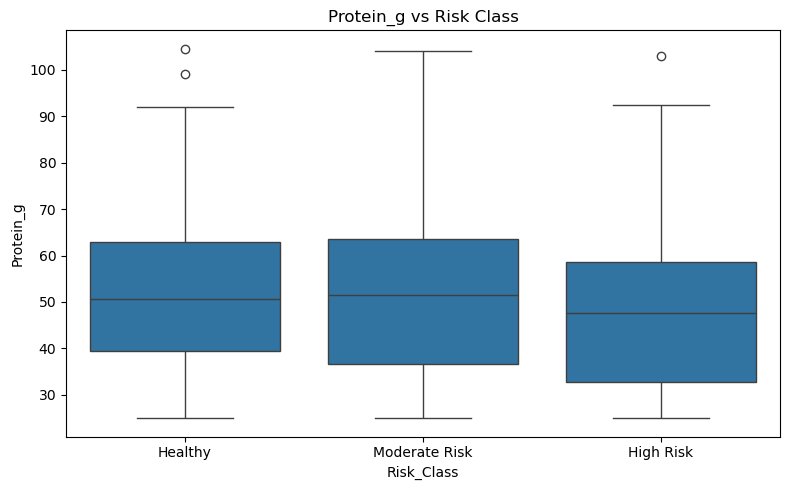

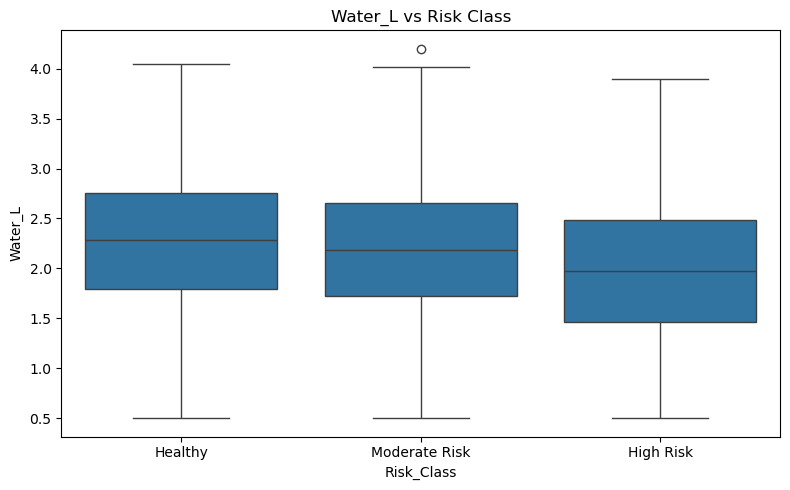

In [109]:
important_features = [
    "BMI",
    "Sleep_Hours",
    "Steps_Per_Day",
    "Fiber_g",
    "Protein_g",
    "Water_L"
]

for feature in important_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=comparison,
        x="Risk_Class",
        y=feature,
        order=[
            "Healthy",
            "Moderate Risk",
            "High Risk"
        ]
    )

    plt.title(f"{feature} vs Risk Class")
    plt.tight_layout()
    plt.show()

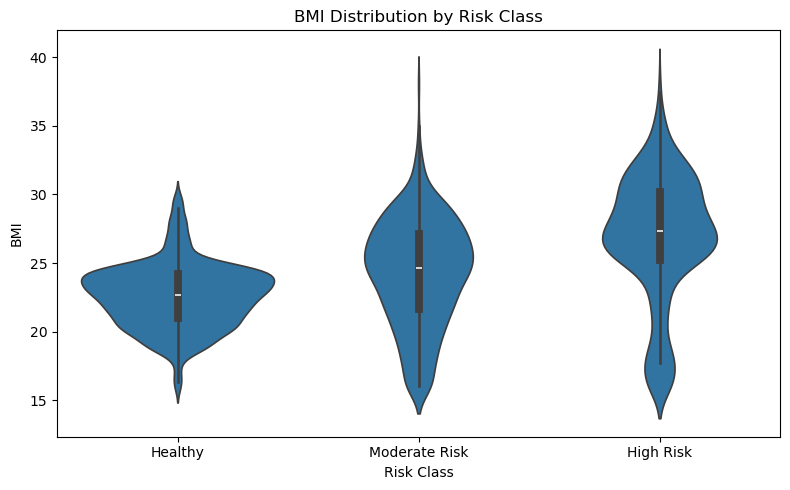

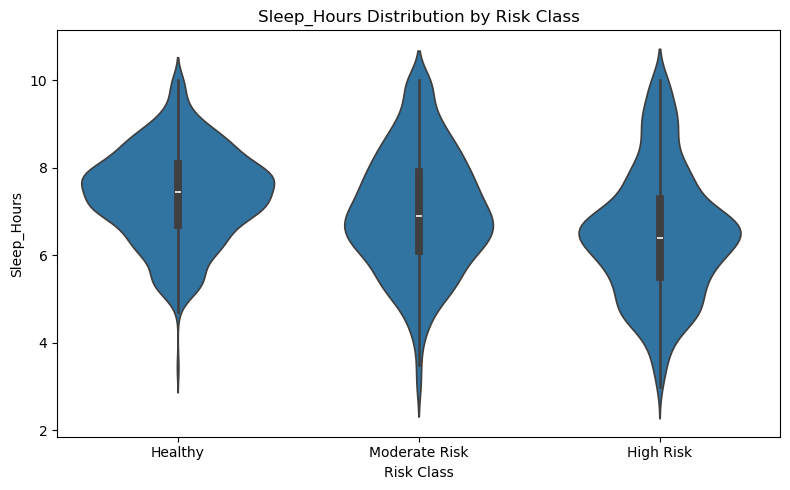

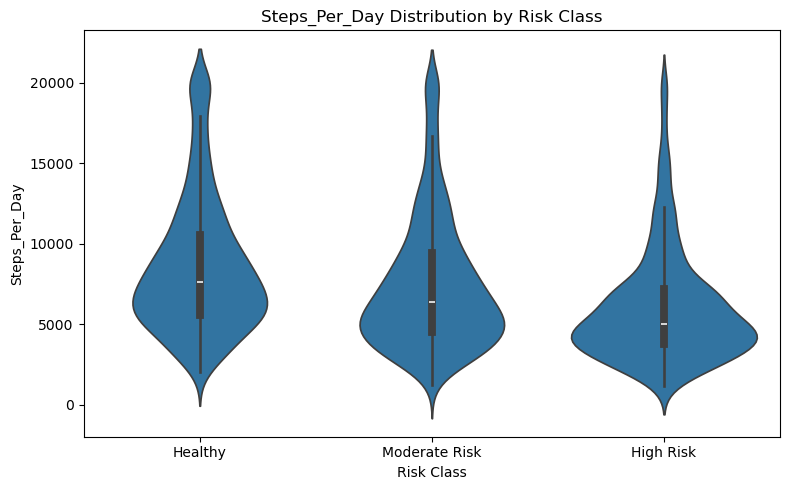

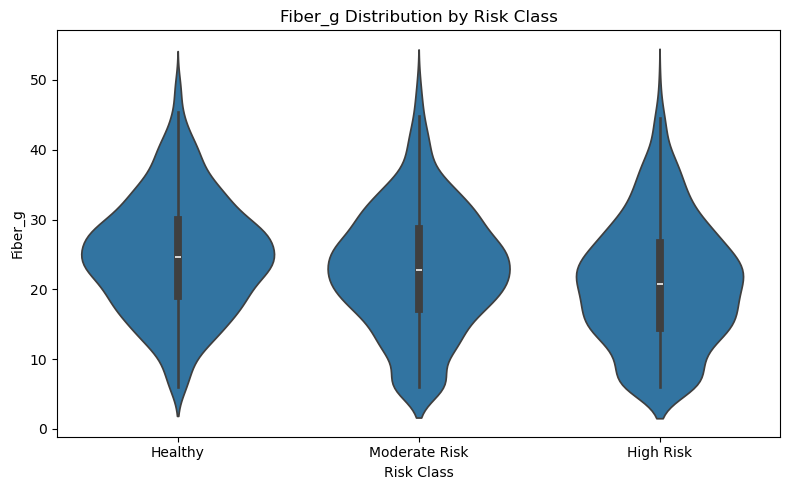

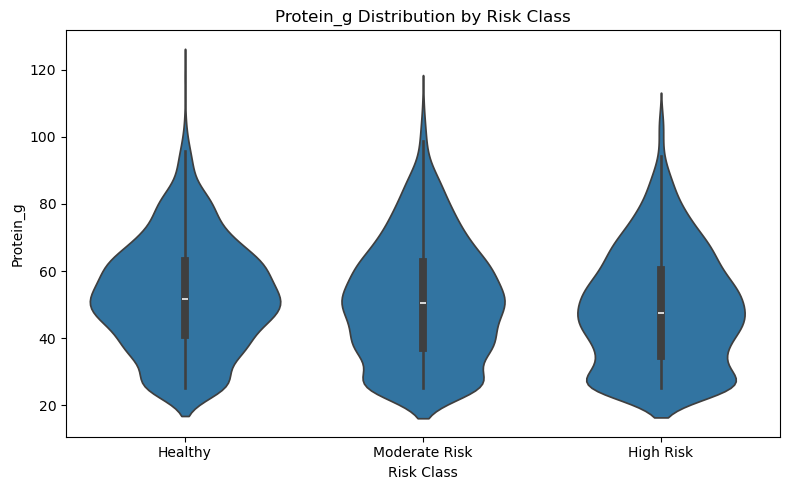

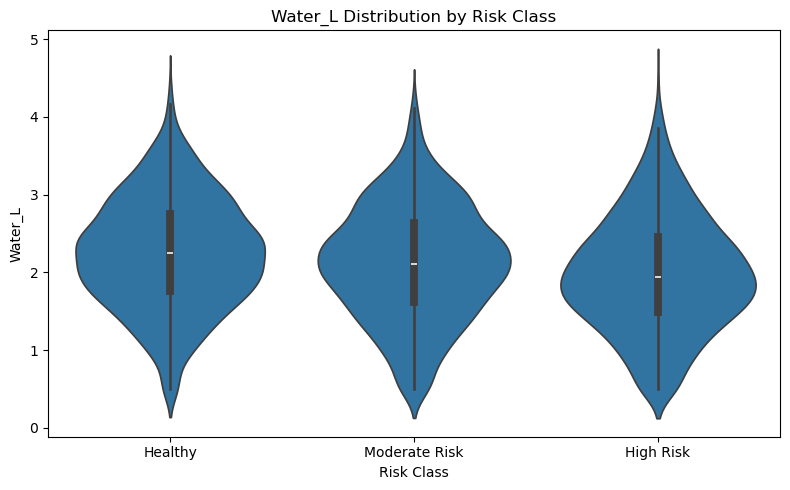

In [110]:
important_features = [
    "BMI",
    "Sleep_Hours",
    "Steps_Per_Day",
    "Fiber_g",
    "Protein_g",
    "Water_L"
]

for feature in important_features:
    plt.figure(figsize=(8, 5))

    sns.violinplot(
        data=df,
        x="Risk_Class",
        y=feature,
        order=[
            "Healthy",
            "Moderate Risk",
            "High Risk"
        ]
    )

    plt.title(f"{feature} Distribution by Risk Class")
    plt.xlabel("Risk Class")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

In [111]:
df.groupby("Risk_Class")[important_features].agg(
    ["mean", "std"]
).round(2)

BMI       Sleep_Hours       Steps_Per_Day          Fiber_g  \
                mean   std        mean   std          mean      std    mean   
Risk_Class                                                                    
Healthy        22.62  2.32        7.38  1.06       8632.95  4217.80   24.87   
High Risk      26.90  4.61        6.48  1.44       6021.34  3493.13   20.88   
Moderate Risk  24.28  3.91        6.99  1.36       7478.66  4102.21   22.87   

                    Protein_g        Water_L        
                std      mean    std    mean   std  
Risk_Class                                          
Healthy        8.23     52.71  16.32    2.25  0.72  
High Risk      8.90     48.72  17.16    1.98  0.75  
Moderate Risk  8.70     51.02  17.66    2.12  0.74

### Misclassified Moderate Risk Analysis

In [113]:
# Test data + actual + predicted combine
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test
error_analysis["Predicted"] = y_pred_final

# Sirf Moderate Risk cases
moderate_cases = error_analysis[
    error_analysis["Actual"] == "Moderate Risk"
].copy()

moderate_cases.head(10)

,Age,Gender,BMI,Daily_Calories_kcal,Protein_g,Fiber_g,Fat_g,Iron_mg,Calcium_mg,Water_L,Steps_Per_Day,Sleep_Hours,Activity_Level,Actual,Predicted
1965,70,Male,24.1,2063,49.5,10.9,117.8,18.9,907,2.24,7469,4.2,Light,Moderate Risk,Moderate Risk
1242,18,Male,25.2,1653,54.0,19.6,44.8,9.6,1342,1.45,9238,8.7,Moderate,Moderate Risk,Moderate Risk
2475,39,Male,16.0,1200,51.0,27.5,47.7,4.7,836,2.87,5608,5.9,Light,Moderate Risk,Moderate Risk
2599,41,Female,22.9,1200,35.0,18.3,75.3,9.5,1193,1.77,6888,6.6,Light,Moderate Risk,Healthy
2334,19,Male,23.0,1434,59.3,17.8,36.7,11.3,1206,2.29,3346,7.4,Light,Moderate Risk,Healthy
2294,48,Male,26.2,1563,75.9,7.3,57.2,12.5,922,1.16,5884,7.1,Light,Moderate Risk,High Risk
2117,70,Male,23.6,1407,27.9,37.8,80.3,13.1,852,1.22,3792,8.1,Light,Moderate Risk,Moderate Risk
1901,60,Male,26.4,1659,63.8,24.1,46.7,13.9,1070,2.27,11236,6.8,Moderate,Moderate Risk,Moderate Risk
2214,43,Female,21.6,1852,36.2,12.0,68.9,14.5,575,1.04,4004,7.1,Light,Moderate Risk,Moderate Risk
2129,59,Female,30.0,1427,64.5,32.8,58.0,17.3,1086,1.88,14285,6.9,Active,Moderate Risk,Moderate Risk


In [114]:
moderate_cases["Prediction_Type"] = np.where(
    moderate_cases["Predicted"] == "Moderate Risk",
    "Correct",
    "Misclassified"
)

moderate_cases.groupby("Prediction_Type")[
    [
        "BMI",
        "Daily_Calories_kcal",
        "Protein_g",
        "Fiber_g",
        "Fat_g",
        "Iron_mg",
        "Calcium_mg",
        "Water_L",
        "Steps_Per_Day",
        "Sleep_Hours"
    ]
].mean().round(2)

,BMI,Daily_Calories_kcal,Protein_g,Fiber_g,Fat_g,Iron_mg,Calcium_mg,Water_L,Steps_Per_Day,Sleep_Hours
Prediction_Type,,,,,,,,,,
Correct,23.90,1635.85,52.82,22.56,61.94,12.09,863.11,2.21,7613.10,6.83
Misclassified,24.31,1640.72,49.68,21.66,61.80,12.40,840.03,2.09,6277.88,6.98


In [115]:
moderate_wrong = moderate_cases[
    moderate_cases["Predicted"] != "Moderate Risk"
]

print("Total Moderate Risk:", len(moderate_cases))
print("Correct:", (moderate_cases["Predicted"] == "Moderate Risk").sum())
print("Wrong:", len(moderate_wrong))

moderate_wrong.head(20)

Total Moderate Risk: 200
Correct: 125
Wrong: 75


,Age,Gender,BMI,Daily_Calories_kcal,Protein_g,Fiber_g,Fat_g,Iron_mg,Calcium_mg,Water_L,Steps_Per_Day,Sleep_Hours,Activity_Level,Actual,Predicted,Prediction_Type
2599,41,Female,22.9,1200,35.0,18.3,75.3,9.5,1193,1.77,6888,6.6,Light,Moderate Risk,Healthy,Misclassified
2334,19,Male,23.0,1434,59.3,17.8,36.7,11.3,1206,2.29,3346,7.4,Light,Moderate Risk,Healthy,Misclassified
2294,48,Male,26.2,1563,75.9,7.3,57.2,12.5,922,1.16,5884,7.1,Light,Moderate Risk,High Risk,Misclassified
2239,37,Male,26.0,1759,36.9,31.2,30.0,20.4,943,2.17,4836,6.1,Light,Moderate Risk,High Risk,Misclassified
475,34,Male,22.3,1459,25.0,24.1,95.0,4.5,447,0.50,7780,7.6,Moderate,Moderate Risk,Healthy,Misclassified
697,31,Male,22.2,2018,29.9,6.0,54.6,10.6,1004,1.15,7475,7.8,Light,Moderate Risk,Healthy,Misclassified
840,37,Female,24.0,1795,38.9,12.2,49.8,15.7,915,2.32,4485,7.5,Light,Moderate Risk,Healthy,Misclassified
1126,26,Male,21.9,1732,52.8,31.1,63.3,17.2,303,0.83,6524,6.8,Light,Moderate Risk,Healthy,Misclassified
528,18,Male,29.8,1601,63.6,35.7,60.4,9.0,738,2.02,5235,6.4,Light,Moderate Risk,High Risk,Misclassified
110,57,Female,24.8,1516,63.7,10.1,83.8,12.7,853,1.75,8016,9.6,Moderate,Moderate Risk,Healthy,Misclassified


In [116]:
moderate_wrong["Predicted"].value_counts()

Predicted
High Risk    40
Healthy      35
Name: count, dtype: int64

In [117]:
moderate_cases.groupby("Prediction_Type")[[
    "BMI",
    "Daily_Calories_kcal",
    "Protein_g",
    "Fiber_g",
    "Water_L",
    "Steps_Per_Day",
    "Sleep_Hours"
]].mean().round(2)

,BMI,Daily_Calories_kcal,Protein_g,Fiber_g,Water_L,Steps_Per_Day,Sleep_Hours
Prediction_Type,,,,,,,
Correct,23.90,1635.85,52.82,22.56,2.21,7613.10,6.83
Misclassified,24.31,1640.72,49.68,21.66,2.09,6277.88,6.98


In [118]:
moderate_wrong["Predicted"].value_counts()

Predicted
High Risk    40
Healthy      35
Name: count, dtype: int64

In [119]:
df["Calorie_Adequacy"] = (
    df["Daily_Calories_kcal"] / 2000
)

df["Protein_Adequacy"] = (
    df["Protein_g"] / 60
)

df["Fiber_Adequacy"] = (
    df["Fiber_g"] / 30
)

df["Hydration_Score"] = (
    df["Water_L"] / 2.5
)

df["Activity_Score"] = (
    df["Steps_Per_Day"] / 8000
)

df["Sleep_Score"] = (
    df["Sleep_Hours"] / 8
)

df["BMI_Risk"] = np.where(
    df["BMI"] < 18.5, 1,
    np.where(
        df["BMI"] < 25, 0,
        np.where(
            df["BMI"] < 30, 1, 2
        )
    )
)

In [120]:
df[
    [
        "Calorie_Adequacy",
        "Protein_Adequacy",
        "Fiber_Adequacy",
        "Hydration_Score",
        "Activity_Score",
        "Sleep_Score",
        "BMI_Risk"
    ]
].head()

,Calorie_Adequacy,Protein_Adequacy,Fiber_Adequacy,Hydration_Score,Activity_Score,Sleep_Score,BMI_Risk
0,0.7380,0.921667,0.843333,0.960,0.640750,1.1500,1
1,0.9155,0.748333,0.526667,0.688,0.312625,0.9750,0
2,0.9485,0.671667,0.430000,0.828,0.867000,1.0750,1
3,0.9295,0.978333,0.966667,1.172,0.576000,1.1125,0
4,1.0290,1.291667,0.663333,0.804,0.637375,0.9125,2


In [121]:
features = [
    "Age",
    "Gender",
    "BMI",
    "Daily_Calories_kcal",
    "Protein_g",
    "Fiber_g",
    "Fat_g",
    "Iron_mg",
    "Calcium_mg",
    "Water_L",
    "Steps_Per_Day",
    "Sleep_Hours",
    "Activity_Level",
    "Calorie_Adequacy",
    "Protein_Adequacy",
    "Fiber_Adequacy",
    "Hydration_Score",
    "Activity_Score",
    "Sleep_Score",
    "BMI_Risk"
]

target = "Risk_Class"

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3000, 20)
y shape: (3000,)


In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (2400, 20)
Testing: (600, 20)


In [123]:
numerical_features = [
    "Age",
    "BMI",
    "Daily_Calories_kcal",
    "Protein_g",
    "Fiber_g",
    "Fat_g",
    "Iron_mg",
    "Calcium_mg",
    "Water_L",
    "Steps_Per_Day",
    "Sleep_Hours",
    "Calorie_Adequacy",
    "Protein_Adequacy",
    "Fiber_Adequacy",
    "Hydration_Score",
    "Activity_Score",
    "Sleep_Score",
    "BMI_Risk"
]

In [124]:
categorical_features = [
    "Gender",
    "Activity_Level"
]

In [125]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

## 5-Model Pipeline

In [126]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        random_state=42
    )
}

In [127]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

print("✅ 5 ML pipelines created")

for name in pipelines:
    print(name)

✅ 5 ML pipelines created
Logistic Regression
Random Forest
Gradient Boosting
Extra Trees
Hist Gradient Boosting


In [128]:
for name, pipeline in pipelines.items():

    pipeline.fit(X_train, y_train)

    print(f"✅ {name} trained")

✅ Logistic Regression trained
✅ Random Forest trained
✅ Gradient Boosting trained
✅ Extra Trees trained
✅ Hist Gradient Boosting trained


### Model Evaluation

In [129]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            average="weighted"
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            average="weighted"
        )
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.781667,0.781440,0.781667,0.781543
1,Gradient Boosting,0.765000,0.765559,0.765000,0.765239
2,Hist Gradient Boosting,0.766667,0.763687,0.766667,0.764799
3,Logistic Regression,0.731667,0.736246,0.731667,0.733299
4,Extra Trees,0.733333,0.732771,0.733333,0.732345


In [130]:
results_percentage = results_df.copy()

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

results_percentage[metrics] = (
    results_percentage[metrics] * 100
).round(2)

results_percentage

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,78.17,78.14,78.17,78.15
1,Gradient Boosting,76.50,76.56,76.50,76.52
2,Hist Gradient Boosting,76.67,76.37,76.67,76.48
3,Logistic Regression,73.17,73.62,73.17,73.33
4,Extra Trees,73.33,73.28,73.33,73.23


In [131]:
best_model_name = results_df.iloc[0]["Model"]

print("🏆 Best Model:", best_model_name)
print(
    "Best F1 Score:",
    round(results_df.iloc[0]["F1 Score"], 4)
)

🏆 Best Model: Random Forest
Best F1 Score: 0.7815


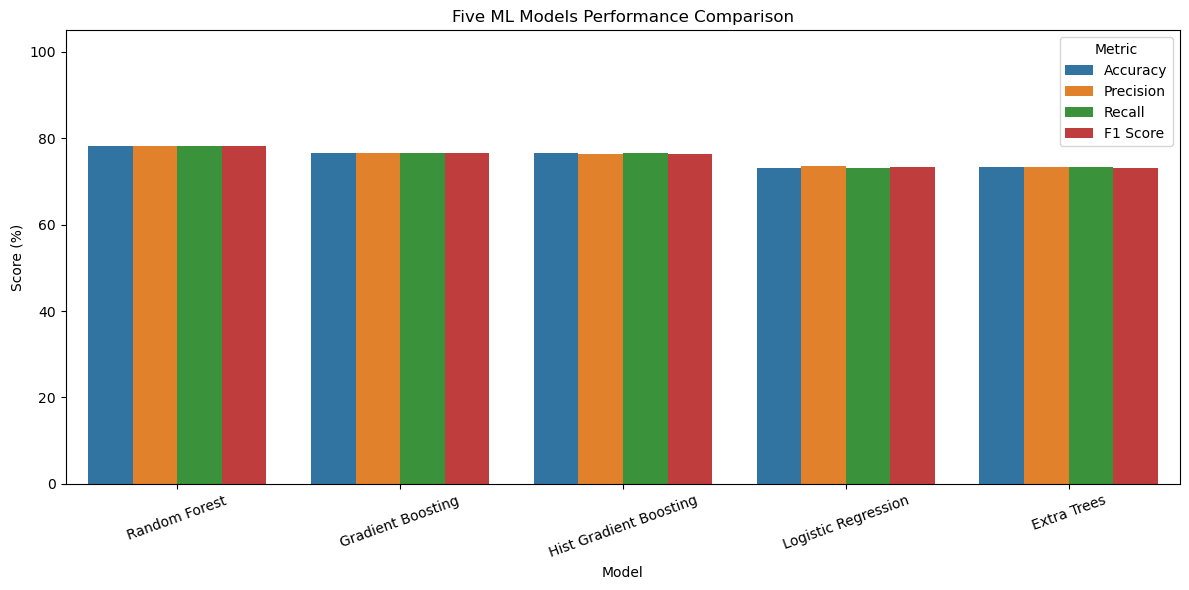

In [132]:
results_melted = results_percentage.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 105)
plt.title("Five ML Models Performance Comparison")
plt.ylabel("Score (%)")
plt.xlabel("Model")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [133]:
# Select Random Forest
final_model = pipelines["Random Forest"]

# Train on complete training data
final_model.fit(X_train, y_train)

print("✅ Final Random Forest trained")

✅ Final Random Forest trained


In [134]:
import joblib

joblib.dump(
    final_model,
    "health_risk_pipeline.pkl"
)

print("✅ Model saved successfully!")

✅ Model saved successfully!
